# LBF EPyMARL Baselines

Runs Random, IQL, MAPPO, and QMIX for the configured Level-Based Foraging episode budget. Random is run locally; IQL, MAPPO, and QMIX are run through an external EPyMARL checkout.


In [1]:
import json
import os
import re
import subprocess
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display

ROOT = Path.cwd()
if ROOT.name == "lbf_grid":
    REPO_ROOT = ROOT.parents[1]
elif (ROOT / "discrete_action_space" / "lbf_grid").exists():
    REPO_ROOT = ROOT
else:
    REPO_ROOT = ROOT.parents[1]
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from discrete_action_space.lbf_grid.epymarl_baselines import (
    EPYMARL_ALGORITHMS,
    _episode_metric_totals,
    _load_episode_metrics,
    n_frames_for_episodes,
    run_epymarl_baseline,
    run_random_policy_baseline,
)
from discrete_action_space.lbf_grid.epymarl_lbf_env import EPYMARL_LBF_SCENARIOS
from discrete_action_space.lbf_grid.notebook_eval import (
    display_rollout_video,
    display_training_reward_plots,
    plot_evaluation_agent_reward_boxplot,
    sample_lbf_rollouts,
)
from discrete_action_space.lbf_grid.pz_wrapper import make_pz_env


In [2]:
N_EPISODES = 5000
EVAL_ROLLOUT_SEED_OFFSET = 50_000
EVAL_VIDEO_FPS = 4
EVAL_EPISODES = 100
SCENARIOS = tuple(EPYMARL_LBF_SCENARIOS)

for key, scenario in EPYMARL_LBF_SCENARIOS.items():
    print(f"{key}: {scenario.description}")
    print(f"  gym_id={scenario.gym_id}")
    print(f"  EPyMARL t_max for {N_EPISODES} episodes = {n_frames_for_episodes(key, N_EPISODES)}")


lbf_8x8_2p_2f_levels12: 2 agents with levels 1 and 2, 8x8 grid, 10 foods (3 level-3, 2 level-2, 5 level-1), full sight, 50-step episodes
  gym_id=SREDQNForaging-8x8-2p-2f-levels12-v0
  EPyMARL t_max for 5000 episodes = 250000
lbf_8x8_2p_2f_force_coop: 2 level-1 agents, 8x8 grid, 10 foods (5 level-1, 5 level-2), full sight, forced cooperation, 50-step episodes
  gym_id=SREDQNForaging-8x8-2p-2f-force-coop-v0
  EPyMARL t_max for 5000 episodes = 250000
lbf_10x10_3p_8f_levels123: 3 agents with levels 1, 2, and 3, 10x10 grid, 18 foods (3 each for levels 1-6), full sight, 100-step episodes
  gym_id=SREDQNForaging-10x10-3p-8f-levels123-v0
  EPyMARL t_max for 5000 episodes = 500000


Set `EPYMARL_ROOT` to a local clone of `https://github.com/uoe-agents/epymarl`. Install EPyMARL dependencies in this same Python environment before running the cell below.

In [3]:
EPYMARL_ROOT = EPYMARL_ROOT = Path("/home/wowthecoder/epymarl")
OUTPUT_ROOT = REPO_ROOT / "discrete_action_space" / "lbf_grid" / "baseline_runs" / "epymarl"
SEED = 2025

if not (EPYMARL_ROOT / "src" / "main.py").exists():
    raise FileNotFoundError(
        f"Set EPYMARL_ROOT to a valid EPyMARL checkout. Missing: {EPYMARL_ROOT / 'src' / 'main.py'}"
    )

CONFIG_OVERRIDES = {
    "runner": "parallel",
    "batch_size_run": 128,
    "use_cuda": True,
    "test_nepisode": 128,
    "save_model": True,
    "save_model_interval": 50_000,
}


In [4]:
def print_stats(record):
    alg = record['algorithm'].upper()
    print(f"\n-- {alg} | {record['scenario_name']} --")
    print(f"  episodes : {record['n_episodes']:,}  |  t_max : {record['t_max']:,}  |  seed : {record['seed']}")
    stats_path = record.get('reward_stats_path') or record.get('stats_path')
    if stats_path and Path(stats_path).exists():
        payload = json.loads(Path(stats_path).read_text())
        reward_stats = payload.get('reward_statistics', {})
        for key, stats in reward_stats.items():
            final = stats.get('final')
            last_100 = stats.get('last_100_mean')
            axis_source = stats.get('episode_axis_source')
            if final is not None:
                print(f"  {key} final logged reward : {final:.4f}")
            if last_100 is not None:
                print(f"  {key} last-100 mean       : {last_100:.4f}")
            if axis_source:
                print(f"  {key} episode axis        : {axis_source}")
    else:
        status = 'OK' if record.get('returncode', 0) == 0 else f"FAILED (code {record['returncode']})"
        print(f"  status : {status}")


def plot_training_rewards(records):
    return display_training_reward_plots(records)


def _scenario_config_from_key(scenario_key):
    scenario = EPYMARL_LBF_SCENARIOS[scenario_key]
    config = dict(scenario.kwargs)
    config["max_food"] = int(config.pop("max_num_food"))
    config["field_size"] = tuple(config["field_size"])
    return config


def _evaluation_boxplot(eval_record, *, title):
    fig = plot_evaluation_agent_reward_boxplot(eval_record, title=title)
    if fig is not None:
        display(fig)
        plt.close(fig)
    return fig


def _print_eval_reward_summary(prefix, eval_record):
    rewards = np.asarray(eval_record.get("episode_rewards", []), dtype=float)
    if rewards.size == 0:
        print(f"{prefix}: no evaluation rewards captured")
        return
    if rewards.ndim == 1:
        rewards = rewards.reshape(-1, 1)
    mean = rewards.mean(axis=0)
    std = rewards.std(axis=0)
    print(f"{prefix}: {rewards.shape[0]} eval episode(s)")
    for i, (m, s) in enumerate(zip(mean, std)):
        label = "shared reward" if rewards.shape[1] == 1 else f"agent_{i}"
        print(f"  {label}: mean={m:.4f}, std={s:.4f}")


def display_random_evaluation_rollouts(records):
    eval_records = {}
    for record in records:
        config = _scenario_config_from_key(record["scenario_key"])
        seed = int(record["seed"]) + EVAL_ROLLOUT_SEED_OFFSET

        def policy_fn(**kwargs):
            env = kwargs["env"]
            return [env.action_space(agent).sample() for agent in kwargs["agent_order"]]

        eval_record = sample_lbf_rollouts(
            make_env=lambda config=config: make_pz_env(**config, render_mode="rgb_array"),
            policy_fn=policy_fn,
            seed=seed,
            n_episodes=EVAL_EPISODES,
            max_steps=int(config["max_episode_steps"]),
        )
        eval_record.update({
            "algorithm": record["algorithm"],
            "scenario_key": record["scenario_key"],
            "episode_metric_totals": eval_record.get("metric_totals", {}),
            "agent_labels": [f"Agent {i + 1}" for i in range(len(eval_record["episode_rewards"][0]))] if eval_record["episode_rewards"] else None,
        })
        eval_path = Path(record["reward_stats_path"]).with_name("eval_episode_rewards.json")
        eval_metrics_path = Path(record["reward_stats_path"]).with_name("evaluation_episode_metrics.json")
        eval_metrics_path.write_text(json.dumps(eval_record.get("episode_metrics", []), indent=2))
        eval_record["episode_metrics_path"] = str(eval_metrics_path)
        eval_path.write_text(json.dumps({
            "algorithm": eval_record["algorithm"],
            "scenario_key": eval_record["scenario_key"],
            "episode_rewards": eval_record["episode_rewards"],
            "episode_metrics": eval_record.get("episode_metrics", []),
            "episode_metric_totals": eval_record["episode_metric_totals"],
            "episode_metrics_path": str(eval_metrics_path),
        }, indent=2))
        _print_eval_reward_summary(f"Random {record['scenario_key']}", eval_record)
        display_rollout_video(
            eval_record["frames"],
            fps=EVAL_VIDEO_FPS,
            title=f"Random evaluation rollout - {record['scenario_key']}",
            render_error=eval_record.get("render_error"),
            output_path=Path(record["reward_stats_path"]).with_name("random_rollout.gif"),
        )
        _evaluation_boxplot(
            eval_record,
            title=f"Random {record['scenario_key']} evaluation rewards",
        )
        eval_records[record["scenario_key"]] = eval_record
    return eval_records



def _latest_epymarl_checkpoint_root(record):
    recorded_root = record.get("model_root")
    if recorded_root and Path(recorded_root).exists():
        return Path(recorded_root)

    deterministic_root = (
        OUTPUT_ROOT
        / "models"
        / record["scenario_key"]
        / str(int(record["seed"]))
        / record["algorithm"]
    )
    if deterministic_root.exists():
        return deterministic_root

    # Backward-compatible fallback for older timestamped runs already on disk.
    model_base = OUTPUT_ROOT / "models"
    token_prefix = (
        f"{record['scenario_key']}_{record['algorithm']}_seed{record['seed']}"
        f"_seed{record['seed']}_{record['gym_id']}_"
    )
    candidates = [path for path in model_base.glob(f"{token_prefix}*") if path.is_dir()]
    if not candidates:
        return None
    return max(candidates, key=lambda path: path.stat().st_mtime)


def run_epymarl_evaluation_rollouts(records, *, common_reward=False):
    eval_records = {}
    for record in records:
        checkpoint_root = _latest_epymarl_checkpoint_root(record)
        if checkpoint_root is None:
            print(
                f"No saved EPyMARL checkpoint for {record['algorithm']} {record['scenario_key']}. "
                "Rerun training with CONFIG_OVERRIDES['save_model']=True to enable checkpoint evaluation."
            )
            continue

        scenario = EPYMARL_LBF_SCENARIOS[record["scenario_key"]]
        reward_stats_path = Path(record["reward_stats_path"])
        if not reward_stats_path.is_absolute():
            reward_stats_path = REPO_ROOT / reward_stats_path
        run_dir = reward_stats_path.parent
        eval_returns_path = run_dir / "eval_episode_rewards.json"
        rollout_video_path = run_dir / f"{record['algorithm']}_rollout.gif"
        eval_metrics_dir = run_dir / "episode_metrics" / "evaluation"
        eval_metrics_path = run_dir / "evaluation_episode_metrics.json"
        run_dir.mkdir(parents=True, exist_ok=True)
        eval_metrics_dir.mkdir(parents=True, exist_ok=True)
        eval_returns_path.unlink(missing_ok=True)
        rollout_video_path.unlink(missing_ok=True)
        eval_metrics_path.unlink(missing_ok=True)
        for metrics_file in eval_metrics_dir.glob("*.jsonl"):
            metrics_file.unlink()
        overrides = [
            f"--config={record['algorithm']}",
            "--env-config=gymma",
            "with",
            f"env_args.time_limit={scenario.time_limit}",
            f"env_args.key={scenario.gym_id}",
            f"seed={record['seed']}",
            f"name={record['scenario_key']}_{record['algorithm']}_eval_seed{record['seed']}",
            f"common_reward={str(bool(common_reward))}",
            f"local_results_path={str(OUTPUT_ROOT)}",
            f"checkpoint_path={str(checkpoint_root)}",
            "evaluate=True",
            "render=False",
            "runner=episode",
            f"test_nepisode={int(EVAL_EPISODES)}",
            "batch_size_run=1",
            "use_cuda=True",
        ]
        patch_code = """
from envs.gymma import GymmaWrapper
from runners.episode_runner import EpisodeRunner

VIDEO_FRAMES = []
VIDEO_DONE = False


def _state_frame(env):
    try:
        from discrete_action_space.lbf_grid.notebook_eval import lbf_state_frame
        return lbf_state_frame(env)
    except Exception as exc:
        print(f'[checkpoint frame capture skipped: {type(exc).__name__}: {exc}]')
        return None


def _append_frame(env):
    global VIDEO_DONE
    if VIDEO_DONE:
        return
    frame = _state_frame(env)
    if frame is not None:
        VIDEO_FRAMES.append(frame)


_old_reset = GymmaWrapper.reset
_old_step = GymmaWrapper.step


def patched_reset(self, *args, **kwargs):
    result = _old_reset(self, *args, **kwargs)
    if not VIDEO_FRAMES and not VIDEO_DONE:
        _append_frame(self)
    return result


def patched_step(self, actions):
    global VIDEO_DONE
    result = _old_step(self, actions)
    if not VIDEO_DONE:
        _append_frame(self)
    if bool(result[2]) or bool(result[3]):
        VIDEO_DONE = True
    return result


GymmaWrapper.reset = patched_reset
GymmaWrapper.step = patched_step

_old_log = EpisodeRunner._log


def patched_log(self, returns, stats, prefix):
    if prefix == 'test_':
        payload = {'episode_rewards': np.asarray(returns, dtype=float).tolist()}
        eval_returns_path.write_text(json.dumps(payload, indent=2))
        if VIDEO_FRAMES:
            try:
                from discrete_action_space.lbf_grid.notebook_eval import save_rollout_video
                save_rollout_video(
                    VIDEO_FRAMES,
                    rollout_video_path,
                    fps=eval_video_fps,
                    title=rollout_video_title,
                )
            except Exception as exc:
                print(f'[checkpoint video save skipped: {type(exc).__name__}: {exc}]')
    return _old_log(self, returns, stats, prefix)


EpisodeRunner._log = patched_log
"""
        rollout_video_title = f"{record['algorithm'].upper()} {record['scenario_key']} rollout"
        bootstrap = (
            "import json, runpy, sys; "
            "from pathlib import Path; "
            "import numpy as np; "
            f"eval_returns_path = Path({str(eval_returns_path)!r}); "
            f"rollout_video_path = Path({str(rollout_video_path)!r}); "
            f"eval_video_fps = {int(EVAL_VIDEO_FPS)!r}; "
            f"rollout_video_title = {rollout_video_title!r}; "
            f"epymarl_root = Path({str(EPYMARL_ROOT)!r}); "
            "sys.path.insert(0, str(epymarl_root / 'src')); "
            f"patch_code = {patch_code!r}; exec(patch_code); "
            "from discrete_action_space.lbf_grid.epymarl_lbf_env import register_epymarl_lbf_envs; "
            "register_epymarl_lbf_envs(); "
            "main_path = epymarl_root / 'src' / 'main.py'; "
            "main_source = main_path.read_text(); "
            "main_source = main_source.replace("
            "'ex.observers.append(FileStorageObserver.create(file_obs_path))', "
            "'pass  # notebook checkpoint eval: do not write Sacred FileStorageObserver output'); "
            f"sys.argv = ['main.py'] + {overrides!r}; "
            "exec(compile(main_source, str(main_path), 'exec'), {'__name__': '__main__', '__file__': str(main_path)})"
        )
        env = os.environ.copy()
        pythonpath = [str(REPO_ROOT), str(EPYMARL_ROOT / "src")]
        if env.get("PYTHONPATH"):
            pythonpath.append(env["PYTHONPATH"])
        env["PYTHONPATH"] = os.pathsep.join(pythonpath)
        env["SREDQN_LBF_METRICS_DIR"] = str(eval_metrics_dir)
        env["SREDQN_LBF_METRICS_RUN_ID"] = (
            f"{record['scenario_key']}_{record['algorithm']}_eval_seed{record['seed']}"
        )
        env["SREDQN_LBF_METRICS_PHASE"] = "evaluation"
        proc = subprocess.run(
            [sys.executable, "-c", bootstrap],
            cwd=str(EPYMARL_ROOT),
            env=env,
            text=True,
            stdout=subprocess.PIPE,
            stderr=subprocess.PIPE,
            check=False,
        )
        print(
            f"{record['algorithm'].upper()} {record['scenario_key']} checkpoint eval "
            f"({EVAL_EPISODES} episode) returncode={proc.returncode}"
        )
        tail = (proc.stdout + "\n" + proc.stderr)[-2000:].strip()
        if tail:
            print(tail)

        payload = json.loads(eval_returns_path.read_text()) if eval_returns_path.exists() else {}
        episode_metrics = _load_episode_metrics(eval_metrics_dir)
        eval_metrics_path.write_text(json.dumps(episode_metrics, indent=2))
        payload.update({
            "episode_metrics": episode_metrics,
            "episode_metric_totals": _episode_metric_totals(episode_metrics),
            "episode_metrics_path": str(eval_metrics_path),
        })
        eval_returns_path.write_text(json.dumps(payload, indent=2))
        eval_record = {
            "algorithm": record["algorithm"],
            "scenario_key": record["scenario_key"],
            "checkpoint_root": str(checkpoint_root),
            "returncode": int(proc.returncode),
            "episode_rewards": payload.get("episode_rewards", []),
            "episode_metrics": episode_metrics,
            "episode_metric_totals": payload["episode_metric_totals"],
            "episode_metrics_path": str(eval_metrics_path),
            "agent_labels": None if common_reward else [f"Agent {i + 1}" for i in range(scenario.n_agents)],
            "rollout_video_path": str(rollout_video_path) if rollout_video_path.exists() else None,
        }
        _print_eval_reward_summary(f"{record['algorithm'].upper()} {record['scenario_key']}", eval_record)
        if rollout_video_path.exists():
            from IPython.display import FileLink
            display(FileLink(str(rollout_video_path)))
            print(f"[checkpoint rollout video saved: {rollout_video_path}]")
        else:
            print(f"[checkpoint video missing: expected {rollout_video_path}]")
        _evaluation_boxplot(
            eval_record,
            title=f"{record['algorithm'].upper()} {record['scenario_key']} evaluation rewards",
        )
        eval_records[record["scenario_key"]] = eval_record
    return eval_records


## IQL Training

In [8]:
records_iql = []
for i, scenario_key in enumerate(SCENARIOS):
    record = run_epymarl_baseline(
        EPYMARL_ROOT,
        'iql',
        scenario_key,
        n_episodes=N_EPISODES,
        seed=SEED + 1000 * i + 1,
        output_root=OUTPUT_ROOT,
        common_reward=False,
        show_progress=True,
        config_overrides=CONFIG_OVERRIDES,
    )
    records_iql.append(record)
    print_stats(record)


IQL lbf_8x8_2p_2f_levels12:   0%|          | 0/250000 [00:00<?, ?step/s]


-- IQL | 2 agents with levels 1 and 2, 8x8 grid, 10 foods (3 level-3, 2 level-2, 5 level-1), full sight, 50-step episodes --
  episodes : 5,000  |  t_max : 250,000  |  seed : 2026
  agent_0 final logged reward : 0.3708
  agent_0 last-100 mean       : 0.7969
  agent_0 episode axis        : env_step_scaled_to_requested_episode_budget
  agent_1 final logged reward : 0.7405
  agent_1 last-100 mean       : 1.5756
  agent_1 episode axis        : env_step_scaled_to_requested_episode_budget
  total final logged reward : 1.1113
  total last-100 mean       : 2.3725
  total episode axis        : env_step_scaled_to_requested_episode_budget


IQL lbf_8x8_2p_2f_force_coop:   0%|          | 0/250000 [00:00<?, ?step/s]


-- IQL | 2 level-1 agents, 8x8 grid, 10 foods (5 level-1, 5 level-2), full sight, forced cooperation, 50-step episodes --
  episodes : 5,000  |  t_max : 250,000  |  seed : 3026
  agent_0 final logged reward : 0.3593
  agent_0 last-100 mean       : 0.7920
  agent_0 episode axis        : env_step_scaled_to_requested_episode_budget
  agent_1 final logged reward : 0.3103
  agent_1 last-100 mean       : 0.7662
  agent_1 episode axis        : env_step_scaled_to_requested_episode_budget
  total final logged reward : 0.6696
  total last-100 mean       : 1.5583
  total episode axis        : env_step_scaled_to_requested_episode_budget


IQL lbf_10x10_3p_8f_levels123:   0%|          | 0/500000 [00:00<?, ?step/s]


-- IQL | 3 agents with levels 1, 2, and 3, 10x10 grid, 18 foods (3 each for levels 1-6), full sight, 100-step episodes --
  episodes : 5,000  |  t_max : 500,000  |  seed : 4026
  agent_0 final logged reward : 0.0198
  agent_0 last-100 mean       : 0.1475
  agent_0 episode axis        : env_step_scaled_to_requested_episode_budget
  agent_1 final logged reward : 0.3570
  agent_1 last-100 mean       : 0.8184
  agent_1 episode axis        : env_step_scaled_to_requested_episode_budget
  agent_2 final logged reward : 0.7716
  agent_2 last-100 mean       : 1.9340
  agent_2 episode axis        : env_step_scaled_to_requested_episode_budget
  total final logged reward : 1.1484
  total last-100 mean       : 2.8999
  total episode axis        : env_step_scaled_to_requested_episode_budget


## IQL Training Reward Plots

For each scenario: one line plot per non-flat agent with mean/std, then one combined non-flat agent-line plot.

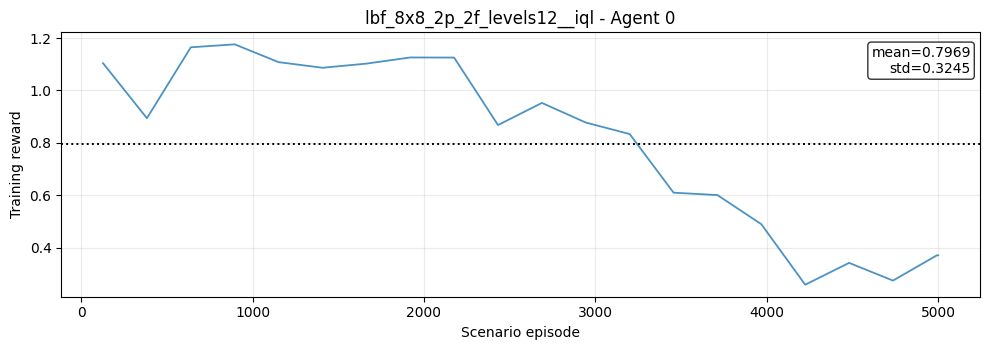

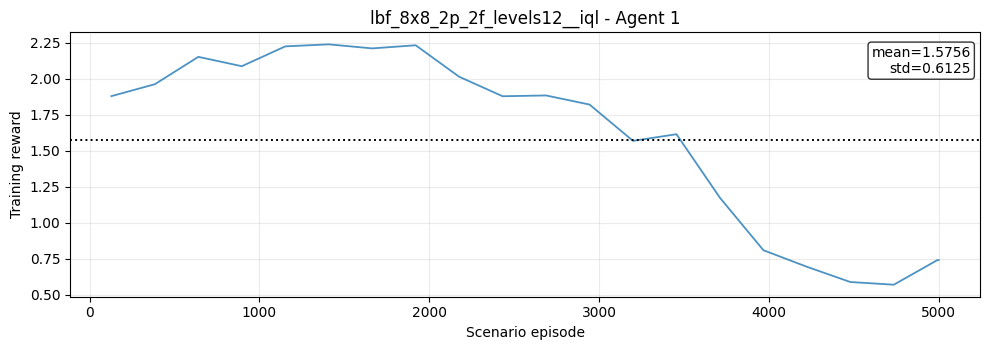

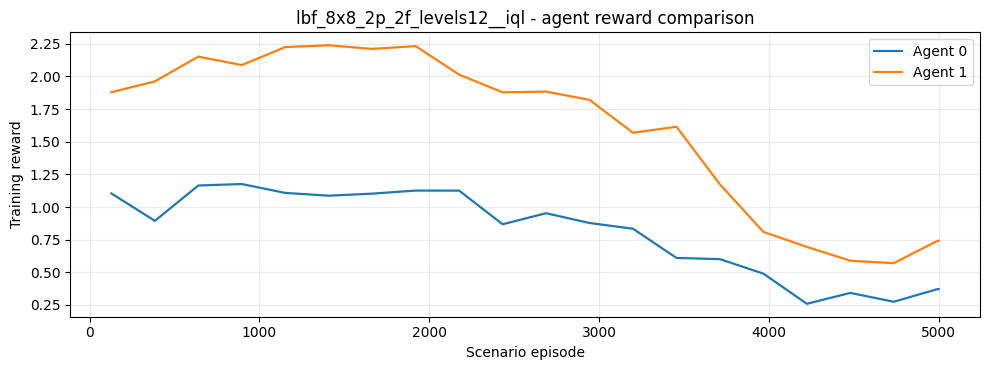

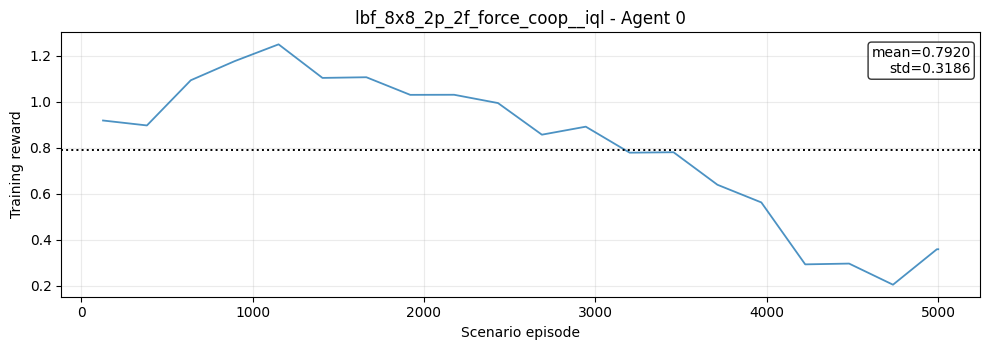

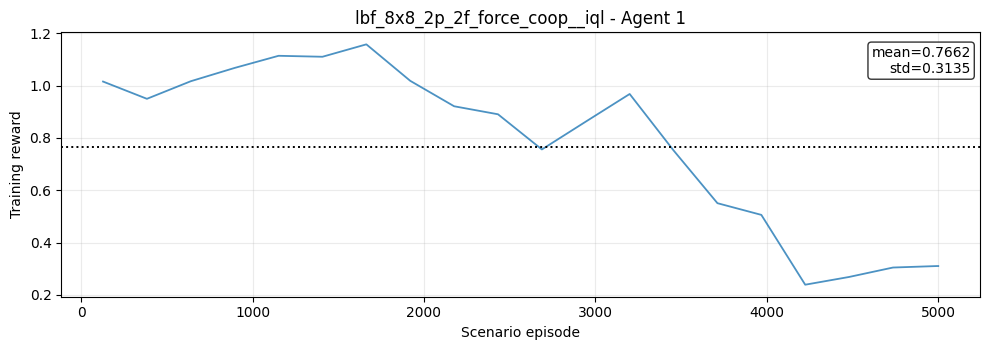

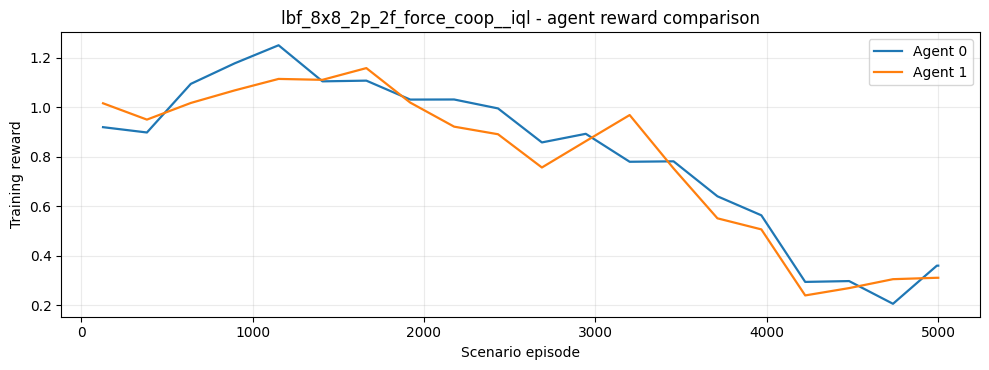

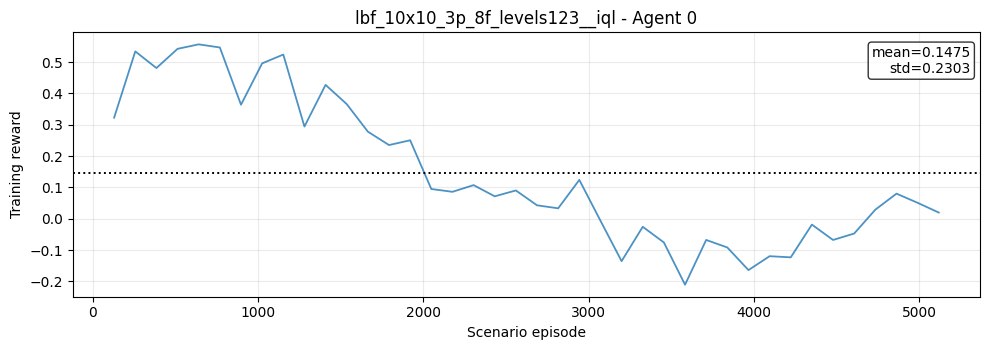

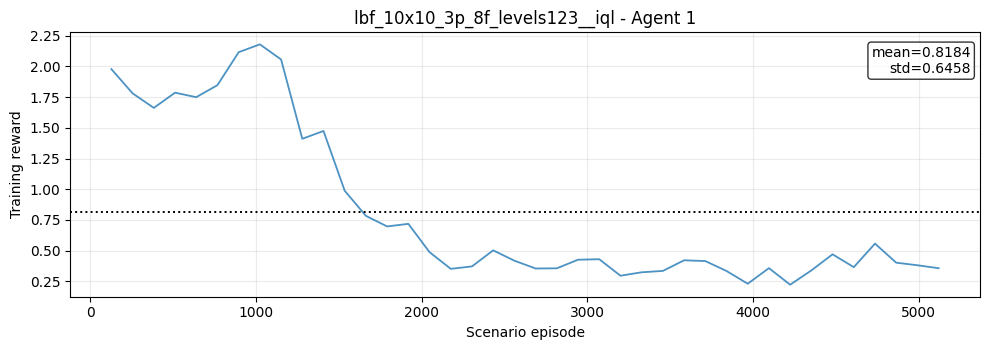

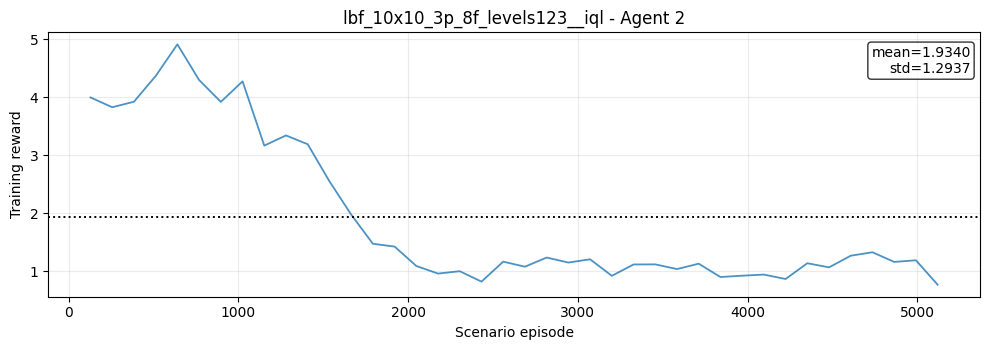

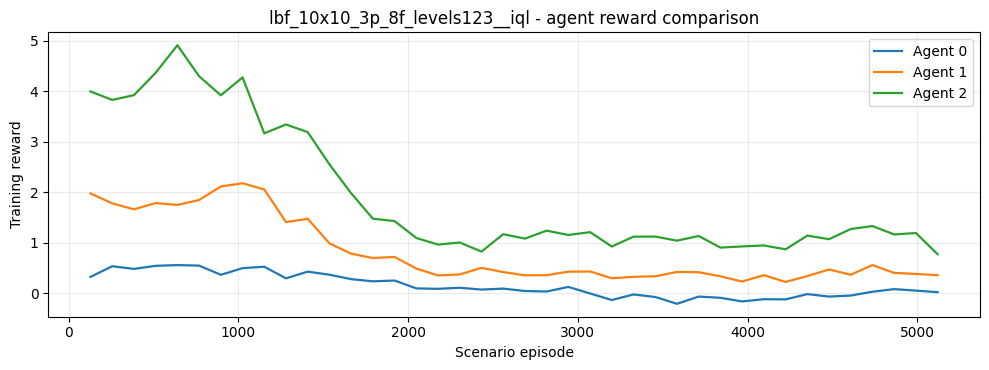

In [9]:
iql_training_figs = plot_training_rewards(records_iql)


## IQL Evaluation Rollouts

For each scenario: run checkpoint evaluation episodes, save/link the first trained-agent rollout GIF, then show one per-agent reward boxplot.

IQL lbf_8x8_2p_2f_levels12 checkpoint eval (100 episode) returncode=0
size='scalable')) = 11.05
[DEBUG 12:39:20] matplotlib.font_manager findfont: score(FontEntry(fname='/usr/share/fonts/truetype/dejavu/DejaVuSerif.ttf', name='DejaVu Serif', style='normal', variant='normal', weight=400, stretch='normal', size='scalable')) = 10.05
[DEBUG 12:39:20] matplotlib.font_manager findfont: score(FontEntry(fname='/usr/share/fonts/truetype/ubuntu/Ubuntu-MI.ttf', name='Ubuntu', style='italic', variant='normal', weight=400, stretch='normal', size='scalable')) = 11.05
[DEBUG 12:39:20] matplotlib.font_manager findfont: score(FontEntry(fname='/usr/share/fonts/truetype/ubuntu/Ubuntu-C.ttf', name='Ubuntu', style='normal', variant='normal', weight=400, stretch='normal', size='scalable')) = 10.05
[DEBUG 12:39:20] matplotlib.font_manager findfont: score(FontEntry(fname='/usr/share/fonts/truetype/ubuntu/Ubuntu-LI.ttf', name='Ubuntu', style='italic', variant='normal', weight=400, stretch='normal', size='scala

/home/wowthecoder/SRE-DQN/discrete_action_space/lbf_grid/baseline_runs/epymarl/lbf_8x8_2p_2f_levels12/iql/iql_rollout.gif

[checkpoint rollout video saved: /home/wowthecoder/SRE-DQN/discrete_action_space/lbf_grid/baseline_runs/epymarl/lbf_8x8_2p_2f_levels12/iql/iql_rollout.gif]


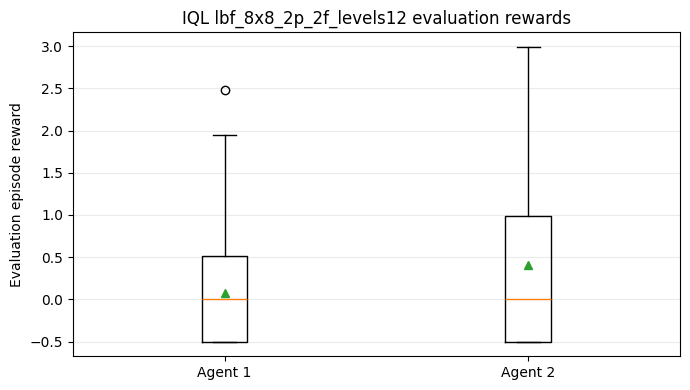

IQL lbf_8x8_2p_2f_force_coop checkpoint eval (100 episode) returncode=0
size='scalable')) = 11.05
[DEBUG 12:39:51] matplotlib.font_manager findfont: score(FontEntry(fname='/usr/share/fonts/truetype/dejavu/DejaVuSerif.ttf', name='DejaVu Serif', style='normal', variant='normal', weight=400, stretch='normal', size='scalable')) = 10.05
[DEBUG 12:39:51] matplotlib.font_manager findfont: score(FontEntry(fname='/usr/share/fonts/truetype/ubuntu/Ubuntu-MI.ttf', name='Ubuntu', style='italic', variant='normal', weight=400, stretch='normal', size='scalable')) = 11.05
[DEBUG 12:39:51] matplotlib.font_manager findfont: score(FontEntry(fname='/usr/share/fonts/truetype/ubuntu/Ubuntu-C.ttf', name='Ubuntu', style='normal', variant='normal', weight=400, stretch='normal', size='scalable')) = 10.05
[DEBUG 12:39:51] matplotlib.font_manager findfont: score(FontEntry(fname='/usr/share/fonts/truetype/ubuntu/Ubuntu-LI.ttf', name='Ubuntu', style='italic', variant='normal', weight=400, stretch='normal', size='sca

/home/wowthecoder/SRE-DQN/discrete_action_space/lbf_grid/baseline_runs/epymarl/lbf_8x8_2p_2f_force_coop/iql/iql_rollout.gif

[checkpoint rollout video saved: /home/wowthecoder/SRE-DQN/discrete_action_space/lbf_grid/baseline_runs/epymarl/lbf_8x8_2p_2f_force_coop/iql/iql_rollout.gif]


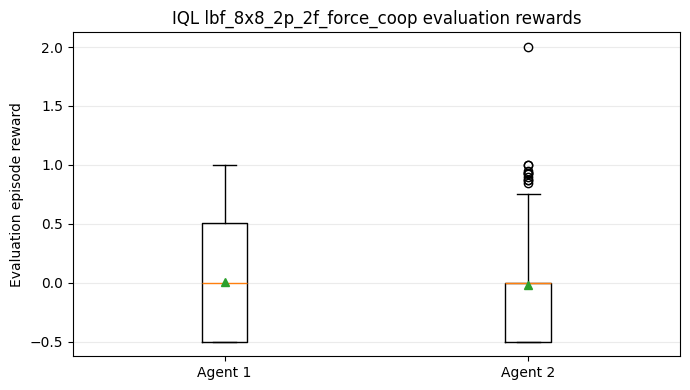

IQL lbf_10x10_3p_8f_levels123 checkpoint eval (100 episode) returncode=0
indfont: score(FontEntry(fname='/usr/share/fonts/truetype/dejavu/DejaVuSerif.ttf', name='DejaVu Serif', style='normal', variant='normal', weight=400, stretch='normal', size='scalable')) = 10.05
[DEBUG 12:40:46] matplotlib.font_manager findfont: score(FontEntry(fname='/usr/share/fonts/truetype/ubuntu/Ubuntu-MI.ttf', name='Ubuntu', style='italic', variant='normal', weight=400, stretch='normal', size='scalable')) = 11.05
[DEBUG 12:40:46] matplotlib.font_manager findfont: score(FontEntry(fname='/usr/share/fonts/truetype/ubuntu/Ubuntu-C.ttf', name='Ubuntu', style='normal', variant='normal', weight=400, stretch='normal', size='scalable')) = 10.05
[DEBUG 12:40:46] matplotlib.font_manager findfont: score(FontEntry(fname='/usr/share/fonts/truetype/ubuntu/Ubuntu-LI.ttf', name='Ubuntu', style='italic', variant='normal', weight=400, stretch='normal', size='scalable')) = 11.05
[DEBUG 12:40:46] matplotlib.font_manager findfont:

/home/wowthecoder/SRE-DQN/discrete_action_space/lbf_grid/baseline_runs/epymarl/lbf_10x10_3p_8f_levels123/iql/iql_rollout.gif

[checkpoint rollout video saved: /home/wowthecoder/SRE-DQN/discrete_action_space/lbf_grid/baseline_runs/epymarl/lbf_10x10_3p_8f_levels123/iql/iql_rollout.gif]


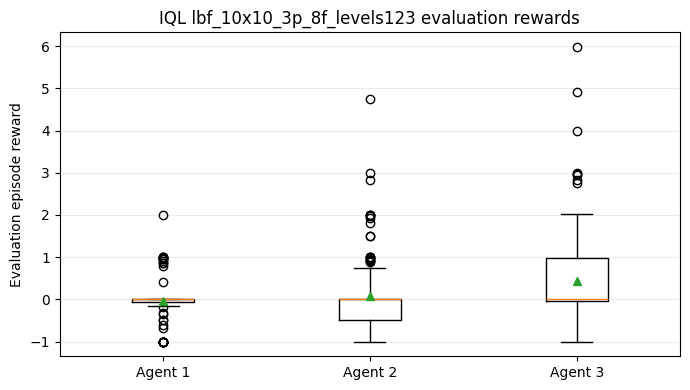

In [16]:
iql_eval_rollouts = run_epymarl_evaluation_rollouts(records_iql, common_reward=False)


## IPPO Training


In [5]:
records_ippo = []
for i, scenario_key in enumerate(SCENARIOS):
    record = run_epymarl_baseline(
        EPYMARL_ROOT,
        'ippo',
        scenario_key,
        n_episodes=N_EPISODES,
        seed=SEED + 1000 * i + 2,
        output_root=OUTPUT_ROOT,
        common_reward=False,
        show_progress=True,
        config_overrides=CONFIG_OVERRIDES,
    )
    records_ippo.append(record)
    print_stats(record)


IPPO lbf_8x8_2p_2f_levels12:   0%|          | 0/250000 [00:00<?, ?step/s]


-- IPPO | 2 agents with levels 1 and 2, 8x8 grid, 10 foods (3 level-3, 2 level-2, 5 level-1), full sight, 50-step episodes --
  episodes : 5,000  |  t_max : 250,000  |  seed : 2027
  agent_0 final logged reward : 1.6941
  agent_0 last-100 mean       : 1.2940
  agent_0 episode axis        : env_step_scaled_to_requested_episode_budget
  agent_1 final logged reward : 3.0205
  agent_1 last-100 mean       : 2.5956
  agent_1 episode axis        : env_step_scaled_to_requested_episode_budget
  total final logged reward : 4.7146
  total last-100 mean       : 3.8895
  total episode axis        : env_step_scaled_to_requested_episode_budget


IPPO lbf_8x8_2p_2f_force_coop:   0%|          | 0/250000 [00:00<?, ?step/s]


-- IPPO | 2 level-1 agents, 8x8 grid, 10 foods (5 level-1, 5 level-2), full sight, forced cooperation, 50-step episodes --
  episodes : 5,000  |  t_max : 250,000  |  seed : 3027
  agent_0 final logged reward : 1.2646
  agent_0 last-100 mean       : 1.2109
  agent_0 episode axis        : env_step_scaled_to_requested_episode_budget
  agent_1 final logged reward : 1.4128
  agent_1 last-100 mean       : 1.2170
  agent_1 episode axis        : env_step_scaled_to_requested_episode_budget
  total final logged reward : 2.6773
  total last-100 mean       : 2.4279
  total episode axis        : env_step_scaled_to_requested_episode_budget


IPPO lbf_10x10_3p_8f_levels123:   0%|          | 0/500000 [00:00<?, ?step/s]


-- IPPO | 3 agents with levels 1, 2, and 3, 10x10 grid, 18 foods (3 each for levels 1-6), full sight, 100-step episodes --
  episodes : 5,000  |  t_max : 500,000  |  seed : 4027
  agent_0 final logged reward : 0.5877
  agent_0 last-100 mean       : 0.4839
  agent_0 episode axis        : env_step_scaled_to_requested_episode_budget
  agent_1 final logged reward : 2.3248
  agent_1 last-100 mean       : 1.8658
  agent_1 episode axis        : env_step_scaled_to_requested_episode_budget
  agent_2 final logged reward : 4.8856
  agent_2 last-100 mean       : 4.3888
  agent_2 episode axis        : env_step_scaled_to_requested_episode_budget
  total final logged reward : 7.7980
  total last-100 mean       : 6.7386
  total episode axis        : env_step_scaled_to_requested_episode_budget


## IPPO Training Reward Plots

For each scenario: one line plot per non-flat agent with mean/std, then one combined non-flat agent-line plot.


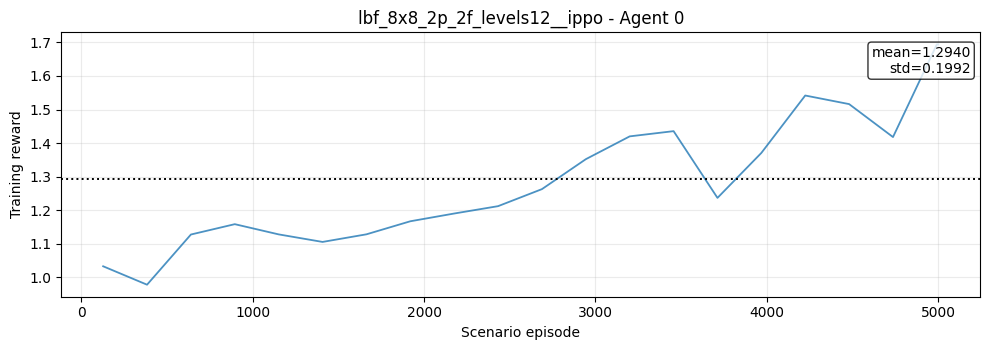

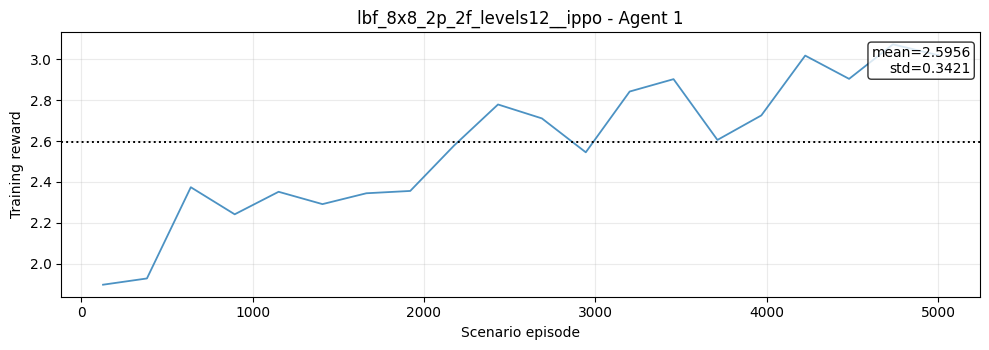

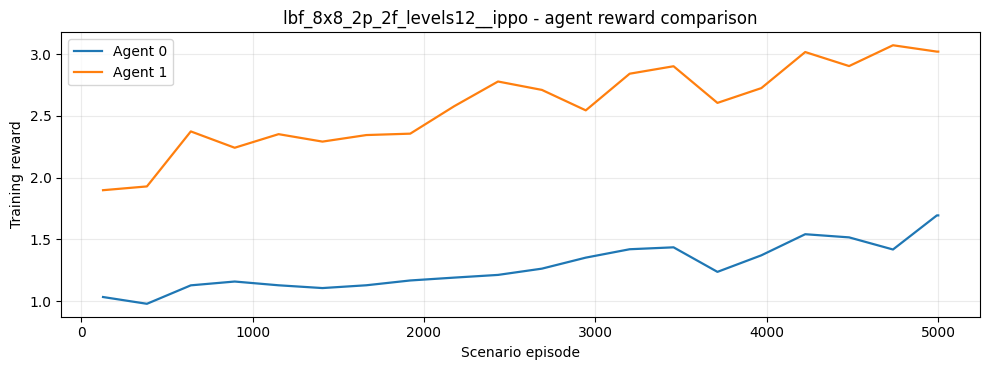

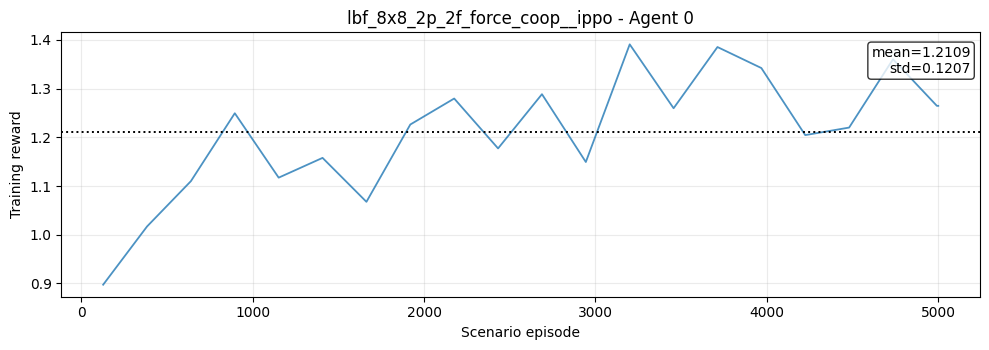

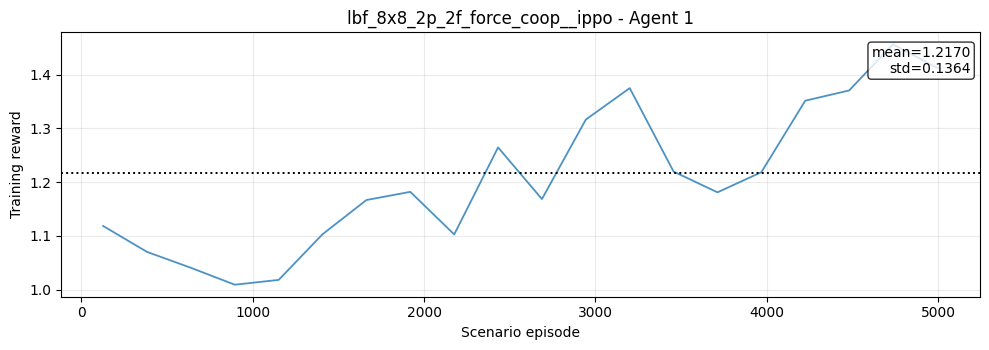

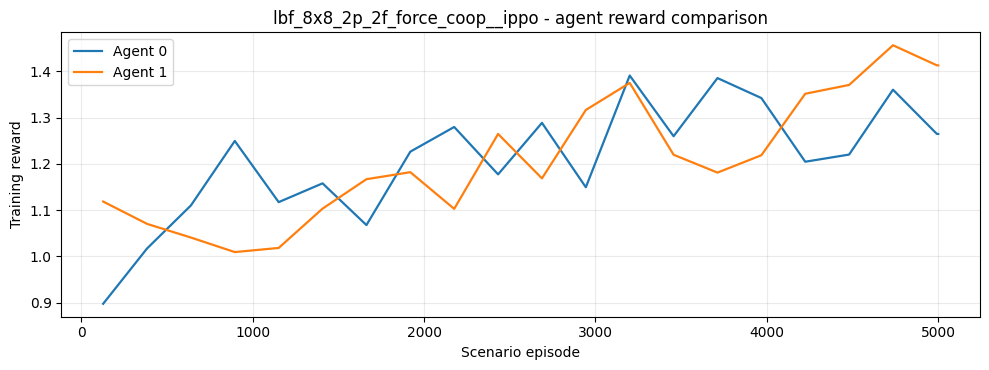

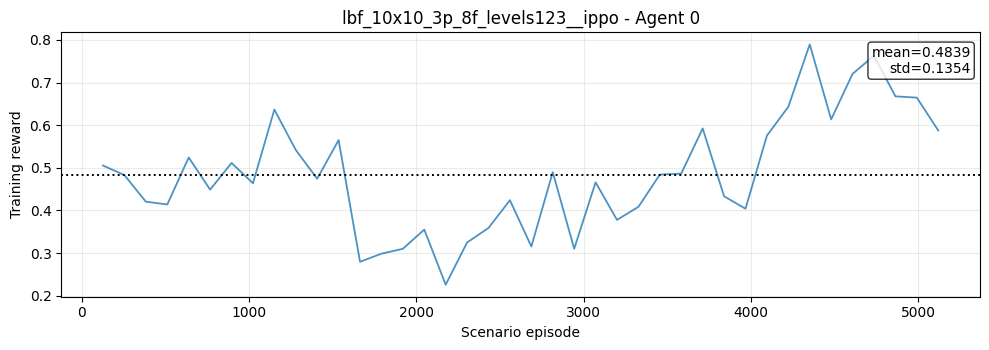

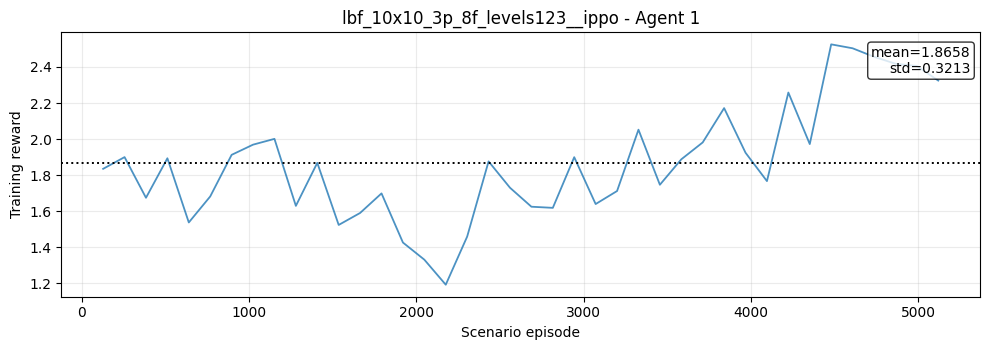

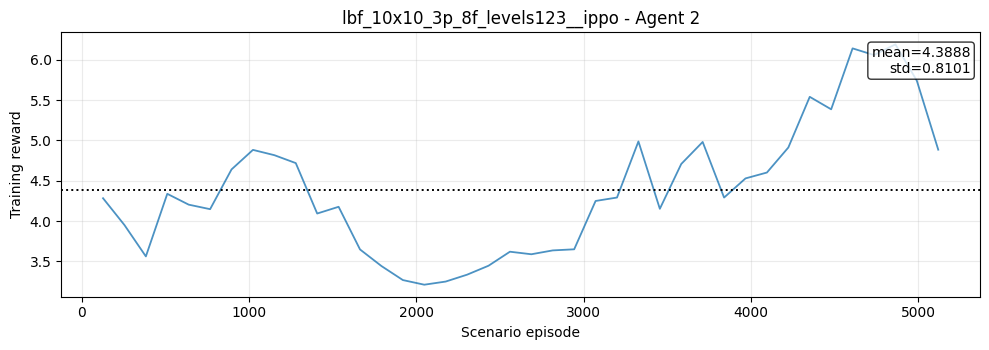

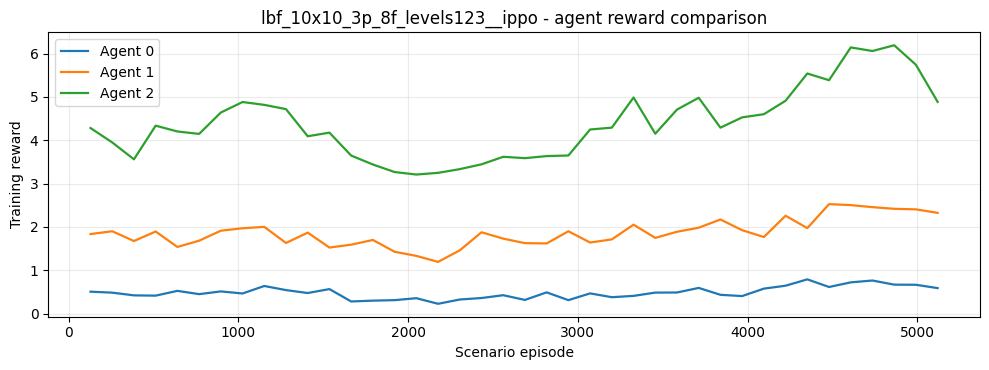

In [6]:
ippo_training_figs = plot_training_rewards(records_ippo)


## IPPO Evaluation Rollouts

For each scenario: run checkpoint evaluation episodes, save/link the first trained-agent rollout GIF, then show one per-agent reward boxplot.


IPPO lbf_8x8_2p_2f_levels12 checkpoint eval (100 episode) returncode=0
size='scalable')) = 11.05
[DEBUG 14:19:16] matplotlib.font_manager findfont: score(FontEntry(fname='/usr/share/fonts/truetype/dejavu/DejaVuSerif.ttf', name='DejaVu Serif', style='normal', variant='normal', weight=400, stretch='normal', size='scalable')) = 10.05
[DEBUG 14:19:16] matplotlib.font_manager findfont: score(FontEntry(fname='/usr/share/fonts/truetype/ubuntu/Ubuntu-MI.ttf', name='Ubuntu', style='italic', variant='normal', weight=400, stretch='normal', size='scalable')) = 11.05
[DEBUG 14:19:16] matplotlib.font_manager findfont: score(FontEntry(fname='/usr/share/fonts/truetype/ubuntu/Ubuntu-C.ttf', name='Ubuntu', style='normal', variant='normal', weight=400, stretch='normal', size='scalable')) = 10.05
[DEBUG 14:19:16] matplotlib.font_manager findfont: score(FontEntry(fname='/usr/share/fonts/truetype/ubuntu/Ubuntu-LI.ttf', name='Ubuntu', style='italic', variant='normal', weight=400, stretch='normal', size='scal

/home/wowthecoder/SRE-DQN/discrete_action_space/lbf_grid/baseline_runs/epymarl/lbf_8x8_2p_2f_levels12/ippo/ippo_rollout.gif

[checkpoint rollout video saved: /home/wowthecoder/SRE-DQN/discrete_action_space/lbf_grid/baseline_runs/epymarl/lbf_8x8_2p_2f_levels12/ippo/ippo_rollout.gif]


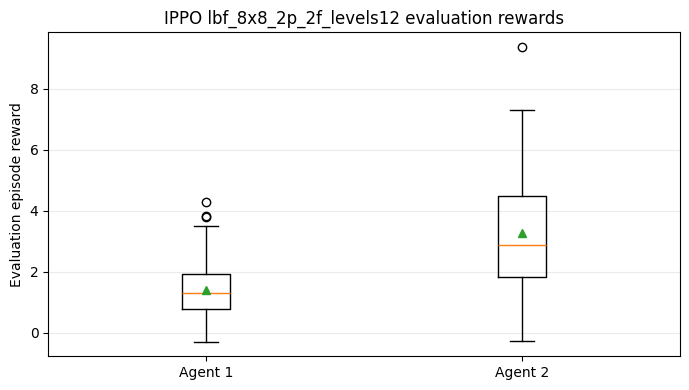

IPPO lbf_8x8_2p_2f_force_coop checkpoint eval (100 episode) returncode=0
size='scalable')) = 11.05
[DEBUG 14:19:42] matplotlib.font_manager findfont: score(FontEntry(fname='/usr/share/fonts/truetype/dejavu/DejaVuSerif.ttf', name='DejaVu Serif', style='normal', variant='normal', weight=400, stretch='normal', size='scalable')) = 10.05
[DEBUG 14:19:42] matplotlib.font_manager findfont: score(FontEntry(fname='/usr/share/fonts/truetype/ubuntu/Ubuntu-MI.ttf', name='Ubuntu', style='italic', variant='normal', weight=400, stretch='normal', size='scalable')) = 11.05
[DEBUG 14:19:42] matplotlib.font_manager findfont: score(FontEntry(fname='/usr/share/fonts/truetype/ubuntu/Ubuntu-C.ttf', name='Ubuntu', style='normal', variant='normal', weight=400, stretch='normal', size='scalable')) = 10.05
[DEBUG 14:19:42] matplotlib.font_manager findfont: score(FontEntry(fname='/usr/share/fonts/truetype/ubuntu/Ubuntu-LI.ttf', name='Ubuntu', style='italic', variant='normal', weight=400, stretch='normal', size='sc

/home/wowthecoder/SRE-DQN/discrete_action_space/lbf_grid/baseline_runs/epymarl/lbf_8x8_2p_2f_force_coop/ippo/ippo_rollout.gif

[checkpoint rollout video saved: /home/wowthecoder/SRE-DQN/discrete_action_space/lbf_grid/baseline_runs/epymarl/lbf_8x8_2p_2f_force_coop/ippo/ippo_rollout.gif]


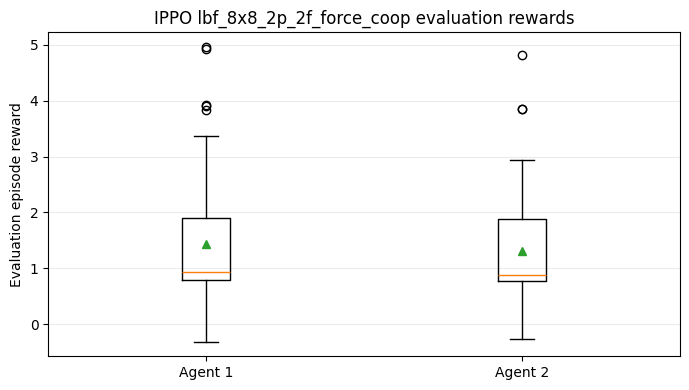

IPPO lbf_10x10_3p_8f_levels123 checkpoint eval (100 episode) returncode=0
indfont: score(FontEntry(fname='/usr/share/fonts/truetype/dejavu/DejaVuSerif.ttf', name='DejaVu Serif', style='normal', variant='normal', weight=400, stretch='normal', size='scalable')) = 10.05
[DEBUG 14:20:30] matplotlib.font_manager findfont: score(FontEntry(fname='/usr/share/fonts/truetype/ubuntu/Ubuntu-MI.ttf', name='Ubuntu', style='italic', variant='normal', weight=400, stretch='normal', size='scalable')) = 11.05
[DEBUG 14:20:30] matplotlib.font_manager findfont: score(FontEntry(fname='/usr/share/fonts/truetype/ubuntu/Ubuntu-C.ttf', name='Ubuntu', style='normal', variant='normal', weight=400, stretch='normal', size='scalable')) = 10.05
[DEBUG 14:20:30] matplotlib.font_manager findfont: score(FontEntry(fname='/usr/share/fonts/truetype/ubuntu/Ubuntu-LI.ttf', name='Ubuntu', style='italic', variant='normal', weight=400, stretch='normal', size='scalable')) = 11.05
[DEBUG 14:20:30] matplotlib.font_manager findfont

/home/wowthecoder/SRE-DQN/discrete_action_space/lbf_grid/baseline_runs/epymarl/lbf_10x10_3p_8f_levels123/ippo/ippo_rollout.gif

[checkpoint rollout video saved: /home/wowthecoder/SRE-DQN/discrete_action_space/lbf_grid/baseline_runs/epymarl/lbf_10x10_3p_8f_levels123/ippo/ippo_rollout.gif]


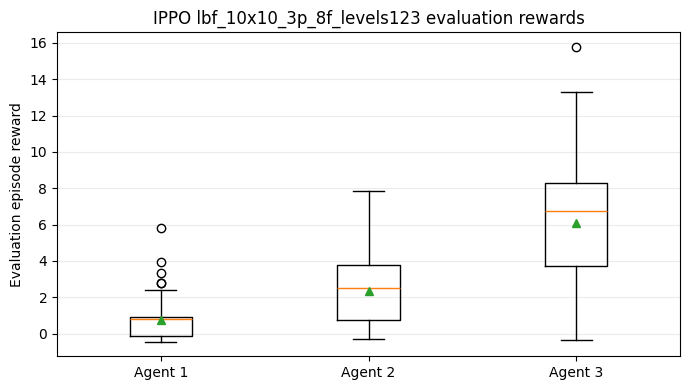

In [7]:
ippo_eval_rollouts = run_epymarl_evaluation_rollouts(records_ippo, common_reward=False)


## MAPPO Training

In [17]:
records_mappo = []
for i, scenario_key in enumerate(SCENARIOS):
    record = run_epymarl_baseline(
        EPYMARL_ROOT,
        'mappo',
        scenario_key,
        n_episodes=N_EPISODES,
        seed=SEED + 1000 * i + 3,
        output_root=OUTPUT_ROOT,
        common_reward=False,
        show_progress=True,
        config_overrides=CONFIG_OVERRIDES,
    )
    records_mappo.append(record)
    print_stats(record)


MAPPO lbf_8x8_2p_2f_levels12:   0%|          | 0/250000 [00:00<?, ?step/s]


-- MAPPO | 2 agents with levels 1 and 2, 8x8 grid, 10 foods (3 level-3, 2 level-2, 5 level-1), full sight, 50-step episodes --
  episodes : 5,000  |  t_max : 250,000  |  seed : 2027
  agent_0 final logged reward : 1.3461
  agent_0 last-100 mean       : 1.1841
  agent_0 episode axis        : env_step_scaled_to_requested_episode_budget
  agent_1 final logged reward : 2.5267
  agent_1 last-100 mean       : 2.3180
  agent_1 episode axis        : env_step_scaled_to_requested_episode_budget
  total final logged reward : 3.8729
  total last-100 mean       : 3.5021
  total episode axis        : env_step_scaled_to_requested_episode_budget


MAPPO lbf_8x8_2p_2f_force_coop:   0%|          | 0/250000 [00:00<?, ?step/s]


-- MAPPO | 2 level-1 agents, 8x8 grid, 10 foods (5 level-1, 5 level-2), full sight, forced cooperation, 50-step episodes --
  episodes : 5,000  |  t_max : 250,000  |  seed : 3027
  agent_0 final logged reward : 1.5257
  agent_0 last-100 mean       : 1.2757
  agent_0 episode axis        : env_step_scaled_to_requested_episode_budget
  agent_1 final logged reward : 1.5607
  agent_1 last-100 mean       : 1.3109
  agent_1 episode axis        : env_step_scaled_to_requested_episode_budget
  total final logged reward : 3.0864
  total last-100 mean       : 2.5866
  total episode axis        : env_step_scaled_to_requested_episode_budget


MAPPO lbf_10x10_3p_8f_levels123:   0%|          | 0/500000 [00:00<?, ?step/s]


-- MAPPO | 3 agents with levels 1, 2, and 3, 10x10 grid, 18 foods (3 each for levels 1-6), full sight, 100-step episodes --
  episodes : 5,000  |  t_max : 500,000  |  seed : 4027
  agent_0 final logged reward : 0.5686
  agent_0 last-100 mean       : 0.5659
  agent_0 episode axis        : env_step_scaled_to_requested_episode_budget
  agent_1 final logged reward : 2.3107
  agent_1 last-100 mean       : 2.0121
  agent_1 episode axis        : env_step_scaled_to_requested_episode_budget
  agent_2 final logged reward : 5.2254
  agent_2 last-100 mean       : 4.7003
  agent_2 episode axis        : env_step_scaled_to_requested_episode_budget
  total final logged reward : 8.1047
  total last-100 mean       : 7.2783
  total episode axis        : env_step_scaled_to_requested_episode_budget


## MAPPO Training Reward Plots

For each scenario: one line plot per non-flat agent with mean/std, then one combined non-flat agent-line plot.

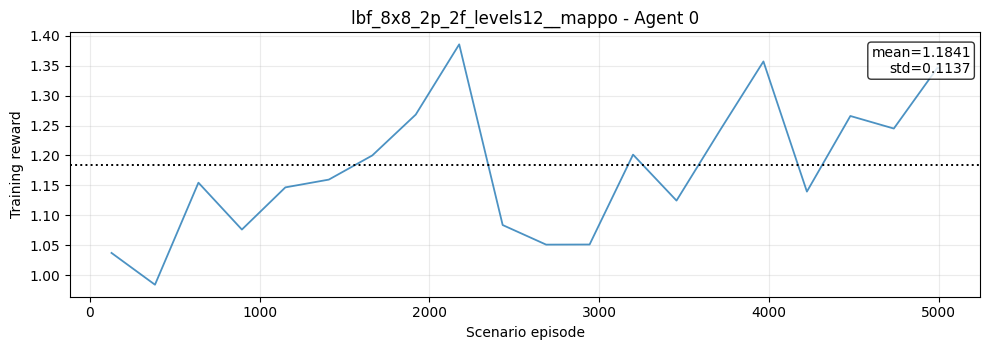

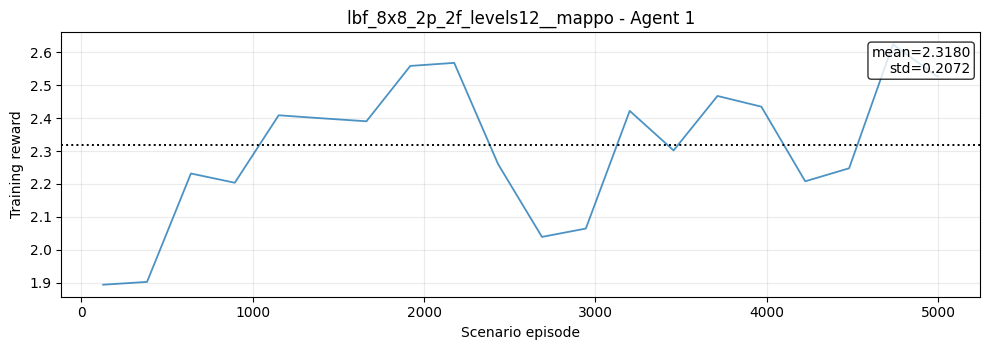

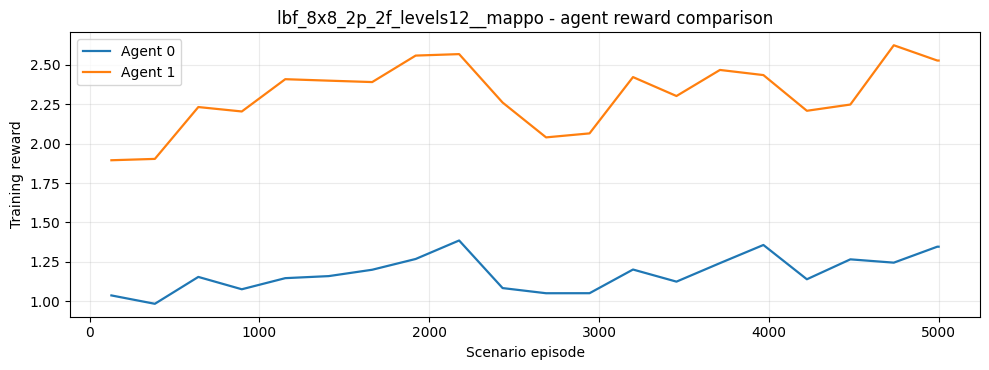

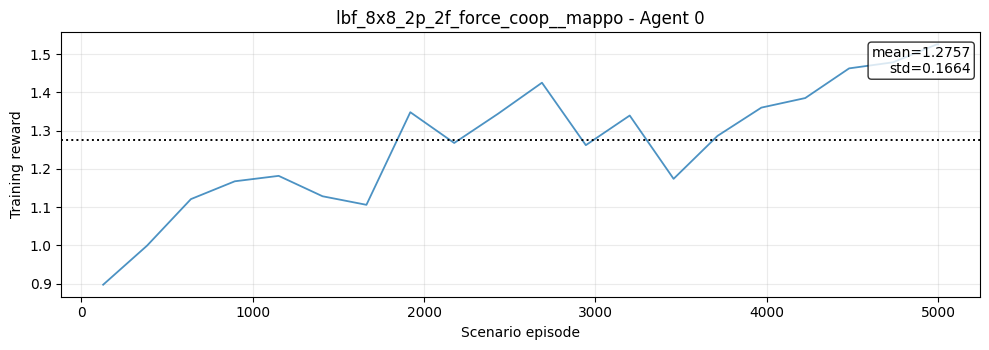

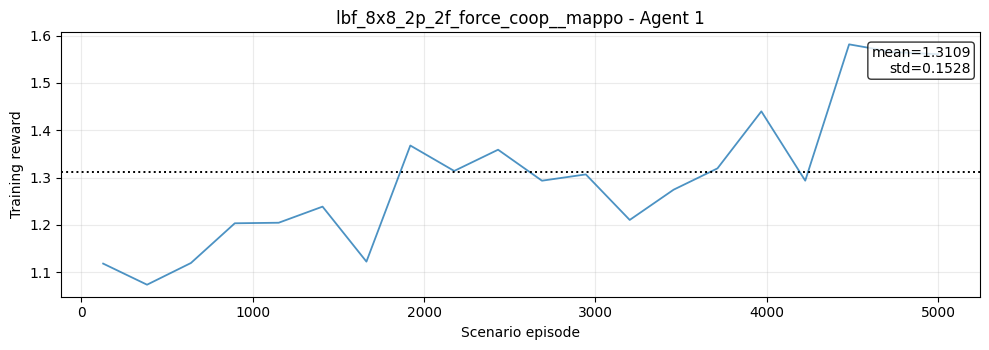

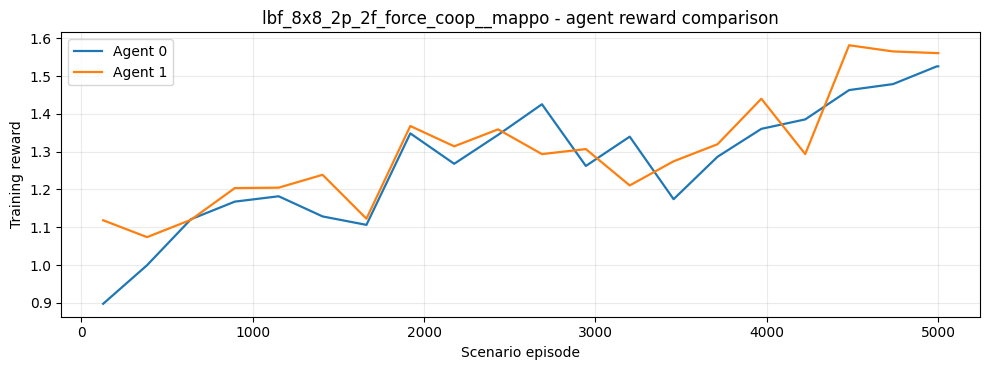

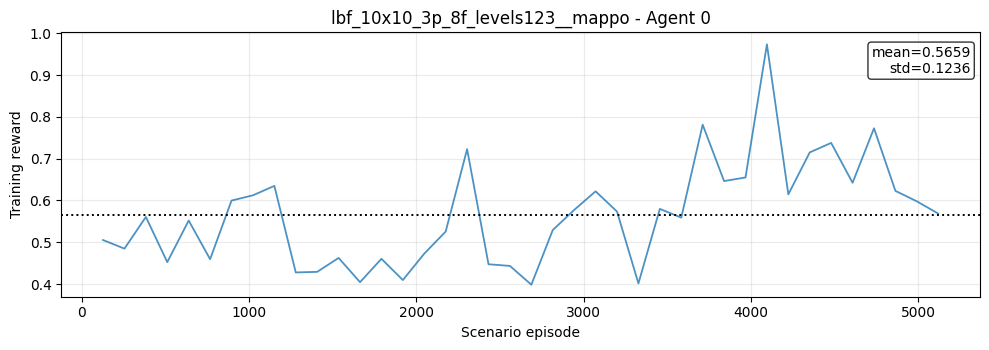

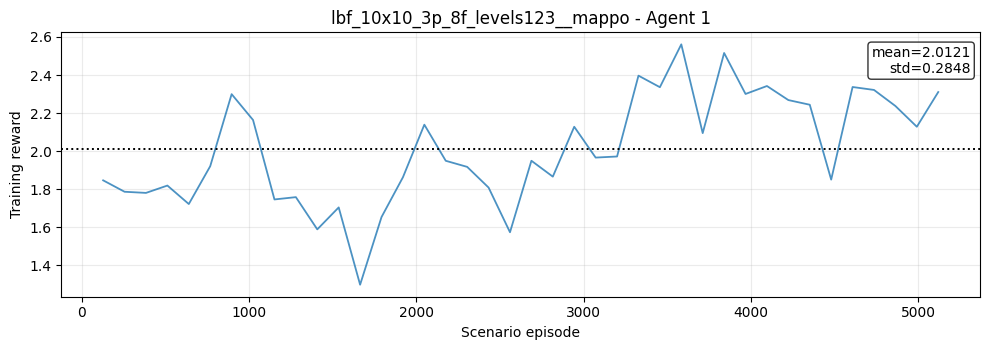

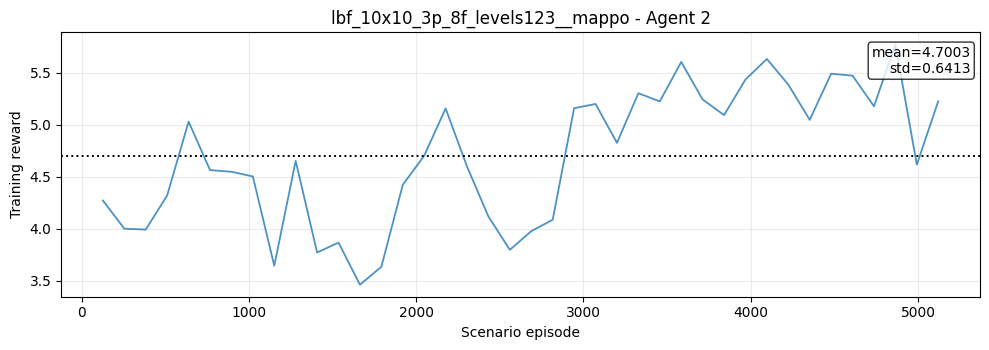

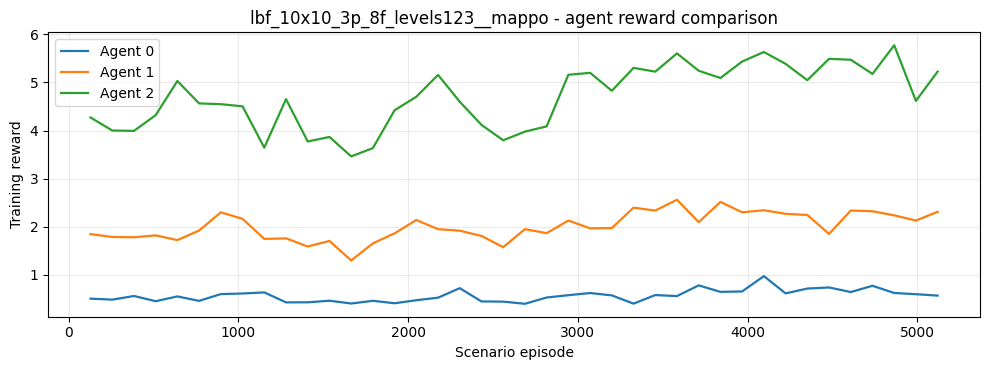

In [18]:
mappo_training_figs = plot_training_rewards(records_mappo)


## MAPPO Evaluation Rollouts

For each scenario: run checkpoint evaluation episodes, save/link the first trained-agent rollout GIF, then show one per-agent reward boxplot.

MAPPO lbf_8x8_2p_2f_levels12 checkpoint eval (100 episode) returncode=0
size='scalable')) = 11.05
[DEBUG 12:58:30] matplotlib.font_manager findfont: score(FontEntry(fname='/usr/share/fonts/truetype/dejavu/DejaVuSerif.ttf', name='DejaVu Serif', style='normal', variant='normal', weight=400, stretch='normal', size='scalable')) = 10.05
[DEBUG 12:58:30] matplotlib.font_manager findfont: score(FontEntry(fname='/usr/share/fonts/truetype/ubuntu/Ubuntu-MI.ttf', name='Ubuntu', style='italic', variant='normal', weight=400, stretch='normal', size='scalable')) = 11.05
[DEBUG 12:58:30] matplotlib.font_manager findfont: score(FontEntry(fname='/usr/share/fonts/truetype/ubuntu/Ubuntu-C.ttf', name='Ubuntu', style='normal', variant='normal', weight=400, stretch='normal', size='scalable')) = 10.05
[DEBUG 12:58:30] matplotlib.font_manager findfont: score(FontEntry(fname='/usr/share/fonts/truetype/ubuntu/Ubuntu-LI.ttf', name='Ubuntu', style='italic', variant='normal', weight=400, stretch='normal', size='sca

/home/wowthecoder/SRE-DQN/discrete_action_space/lbf_grid/baseline_runs/epymarl/lbf_8x8_2p_2f_levels12/mappo/mappo_rollout.gif

[checkpoint rollout video saved: /home/wowthecoder/SRE-DQN/discrete_action_space/lbf_grid/baseline_runs/epymarl/lbf_8x8_2p_2f_levels12/mappo/mappo_rollout.gif]


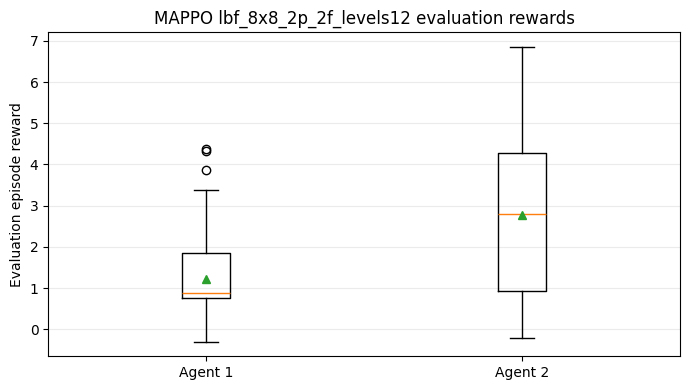

MAPPO lbf_8x8_2p_2f_force_coop checkpoint eval (100 episode) returncode=0
size='scalable')) = 11.05
[DEBUG 12:59:02] matplotlib.font_manager findfont: score(FontEntry(fname='/usr/share/fonts/truetype/dejavu/DejaVuSerif.ttf', name='DejaVu Serif', style='normal', variant='normal', weight=400, stretch='normal', size='scalable')) = 10.05
[DEBUG 12:59:02] matplotlib.font_manager findfont: score(FontEntry(fname='/usr/share/fonts/truetype/ubuntu/Ubuntu-MI.ttf', name='Ubuntu', style='italic', variant='normal', weight=400, stretch='normal', size='scalable')) = 11.05
[DEBUG 12:59:02] matplotlib.font_manager findfont: score(FontEntry(fname='/usr/share/fonts/truetype/ubuntu/Ubuntu-C.ttf', name='Ubuntu', style='normal', variant='normal', weight=400, stretch='normal', size='scalable')) = 10.05
[DEBUG 12:59:02] matplotlib.font_manager findfont: score(FontEntry(fname='/usr/share/fonts/truetype/ubuntu/Ubuntu-LI.ttf', name='Ubuntu', style='italic', variant='normal', weight=400, stretch='normal', size='s

/home/wowthecoder/SRE-DQN/discrete_action_space/lbf_grid/baseline_runs/epymarl/lbf_8x8_2p_2f_force_coop/mappo/mappo_rollout.gif

[checkpoint rollout video saved: /home/wowthecoder/SRE-DQN/discrete_action_space/lbf_grid/baseline_runs/epymarl/lbf_8x8_2p_2f_force_coop/mappo/mappo_rollout.gif]


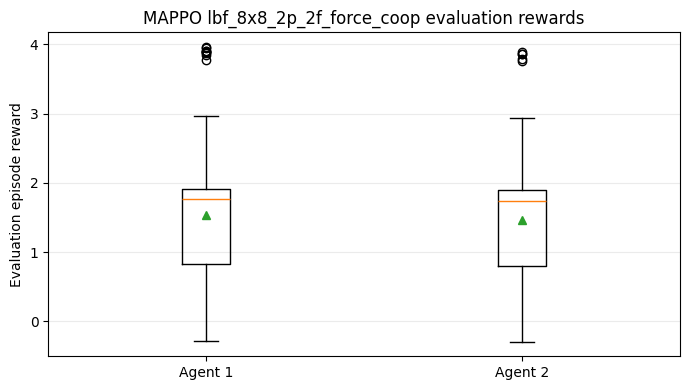

MAPPO lbf_10x10_3p_8f_levels123 checkpoint eval (100 episode) returncode=0
indfont: score(FontEntry(fname='/usr/share/fonts/truetype/dejavu/DejaVuSerif.ttf', name='DejaVu Serif', style='normal', variant='normal', weight=400, stretch='normal', size='scalable')) = 10.05
[DEBUG 12:59:45] matplotlib.font_manager findfont: score(FontEntry(fname='/usr/share/fonts/truetype/ubuntu/Ubuntu-MI.ttf', name='Ubuntu', style='italic', variant='normal', weight=400, stretch='normal', size='scalable')) = 11.05
[DEBUG 12:59:45] matplotlib.font_manager findfont: score(FontEntry(fname='/usr/share/fonts/truetype/ubuntu/Ubuntu-C.ttf', name='Ubuntu', style='normal', variant='normal', weight=400, stretch='normal', size='scalable')) = 10.05
[DEBUG 12:59:45] matplotlib.font_manager findfont: score(FontEntry(fname='/usr/share/fonts/truetype/ubuntu/Ubuntu-LI.ttf', name='Ubuntu', style='italic', variant='normal', weight=400, stretch='normal', size='scalable')) = 11.05
[DEBUG 12:59:45] matplotlib.font_manager findfon

/home/wowthecoder/SRE-DQN/discrete_action_space/lbf_grid/baseline_runs/epymarl/lbf_10x10_3p_8f_levels123/mappo/mappo_rollout.gif

[checkpoint rollout video saved: /home/wowthecoder/SRE-DQN/discrete_action_space/lbf_grid/baseline_runs/epymarl/lbf_10x10_3p_8f_levels123/mappo/mappo_rollout.gif]


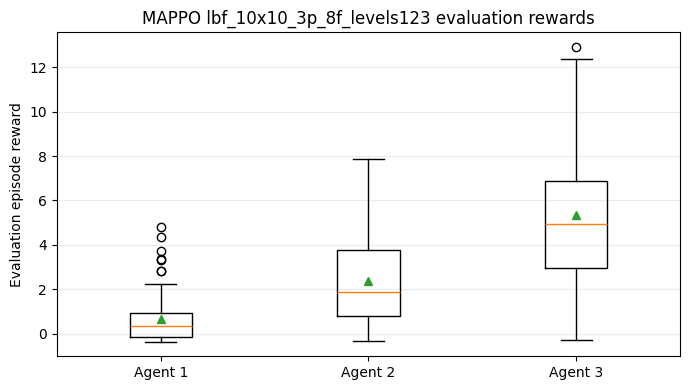

In [19]:
mappo_eval_rollouts = run_epymarl_evaluation_rollouts(records_mappo, common_reward=False)


## MAA2C Training


In [8]:
records_maa2c = []
for i, scenario_key in enumerate(SCENARIOS):
    record = run_epymarl_baseline(
        EPYMARL_ROOT,
        'maa2c',
        scenario_key,
        n_episodes=N_EPISODES,
        seed=SEED + 1000 * i + 5,
        output_root=OUTPUT_ROOT,
        common_reward=False,
        show_progress=True,
        config_overrides=CONFIG_OVERRIDES,
    )
    records_maa2c.append(record)
    print_stats(record)


MAA2C lbf_8x8_2p_2f_levels12:   0%|          | 0/250000 [00:00<?, ?step/s]


-- MAA2C | 2 agents with levels 1 and 2, 8x8 grid, 10 foods (3 level-3, 2 level-2, 5 level-1), full sight, 50-step episodes --
  episodes : 5,000  |  t_max : 250,000  |  seed : 2030
  agent_0 final logged reward : 1.4173
  agent_0 last-100 mean       : 1.2257
  agent_0 episode axis        : env_step_scaled_to_requested_episode_budget
  agent_1 final logged reward : 2.7174
  agent_1 last-100 mean       : 2.4556
  agent_1 episode axis        : env_step_scaled_to_requested_episode_budget
  total final logged reward : 4.1347
  total last-100 mean       : 3.6813
  total episode axis        : env_step_scaled_to_requested_episode_budget


MAA2C lbf_8x8_2p_2f_force_coop:   0%|          | 0/250000 [00:00<?, ?step/s]


-- MAA2C | 2 level-1 agents, 8x8 grid, 10 foods (5 level-1, 5 level-2), full sight, forced cooperation, 50-step episodes --
  episodes : 5,000  |  t_max : 250,000  |  seed : 3030
  agent_0 final logged reward : 1.2429
  agent_0 last-100 mean       : 1.1087
  agent_0 episode axis        : env_step_scaled_to_requested_episode_budget
  agent_1 final logged reward : 1.0996
  agent_1 last-100 mean       : 1.0764
  agent_1 episode axis        : env_step_scaled_to_requested_episode_budget
  total final logged reward : 2.3425
  total last-100 mean       : 2.1852
  total episode axis        : env_step_scaled_to_requested_episode_budget


MAA2C lbf_10x10_3p_8f_levels123:   0%|          | 0/500000 [00:00<?, ?step/s]


-- MAA2C | 3 agents with levels 1, 2, and 3, 10x10 grid, 18 foods (3 each for levels 1-6), full sight, 100-step episodes --
  episodes : 5,000  |  t_max : 500,000  |  seed : 4030
  agent_0 final logged reward : 0.4076
  agent_0 last-100 mean       : 0.5075
  agent_0 episode axis        : env_step_scaled_to_requested_episode_budget
  agent_1 final logged reward : 1.8977
  agent_1 last-100 mean       : 1.9310
  agent_1 episode axis        : env_step_scaled_to_requested_episode_budget
  agent_2 final logged reward : 4.1348
  agent_2 last-100 mean       : 4.4200
  agent_2 episode axis        : env_step_scaled_to_requested_episode_budget
  total final logged reward : 6.4402
  total last-100 mean       : 6.8585
  total episode axis        : env_step_scaled_to_requested_episode_budget


## MAA2C Training Reward Plots

For each scenario: one line plot per non-flat agent with mean/std, then one combined non-flat agent-line plot.


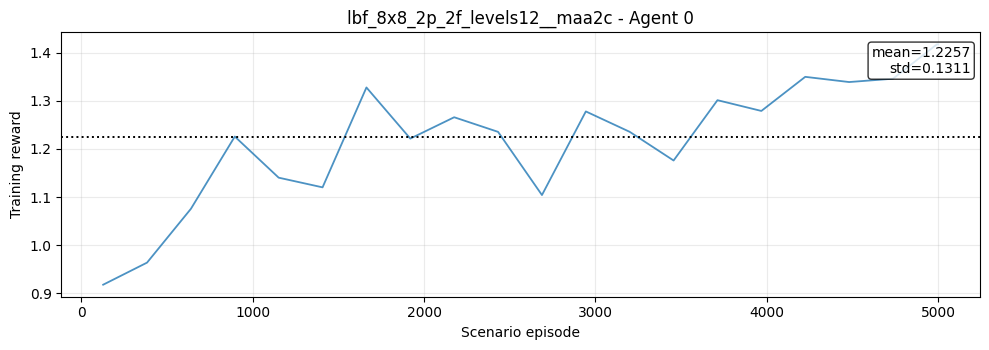

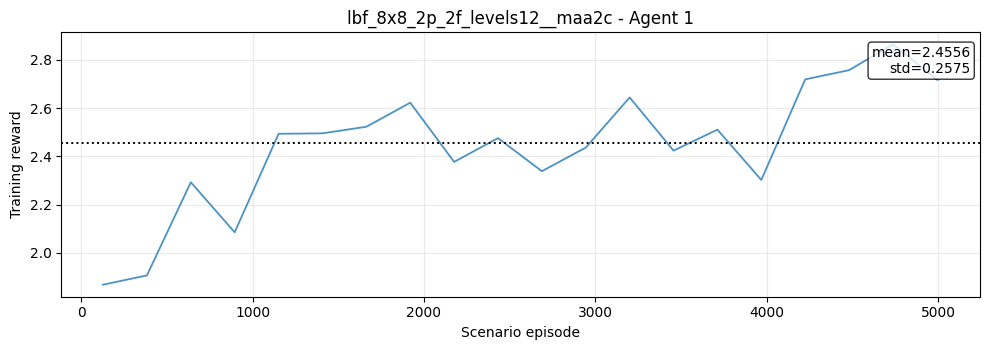

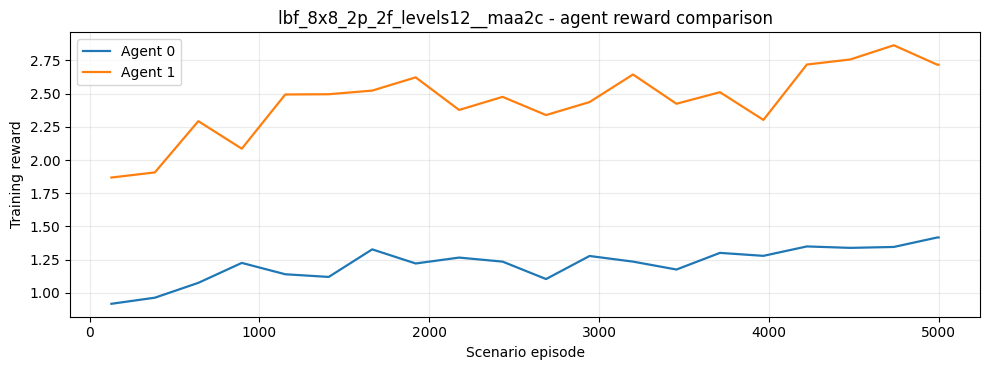

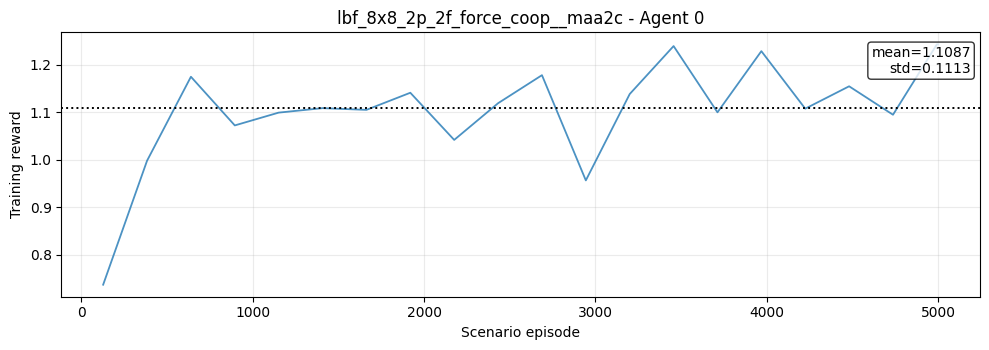

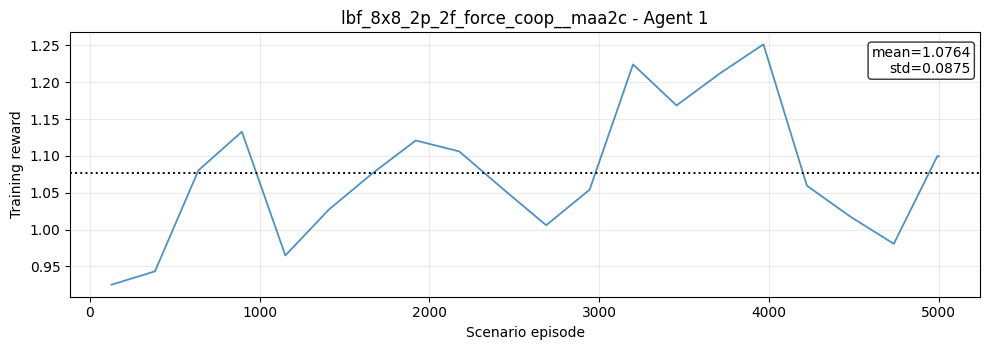

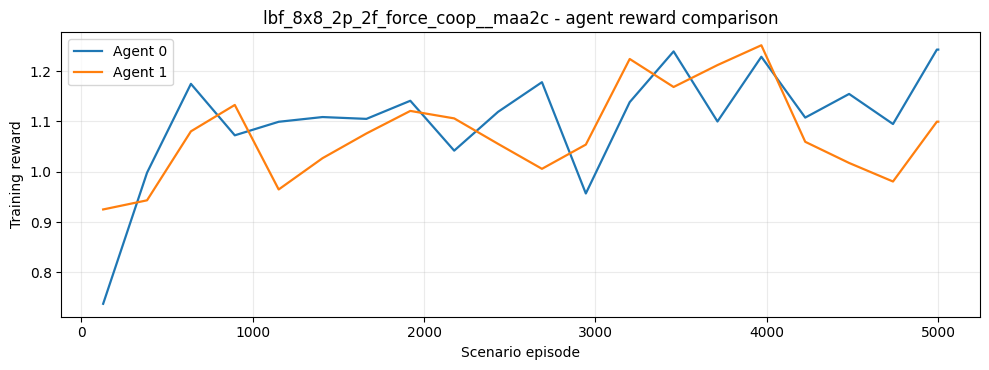

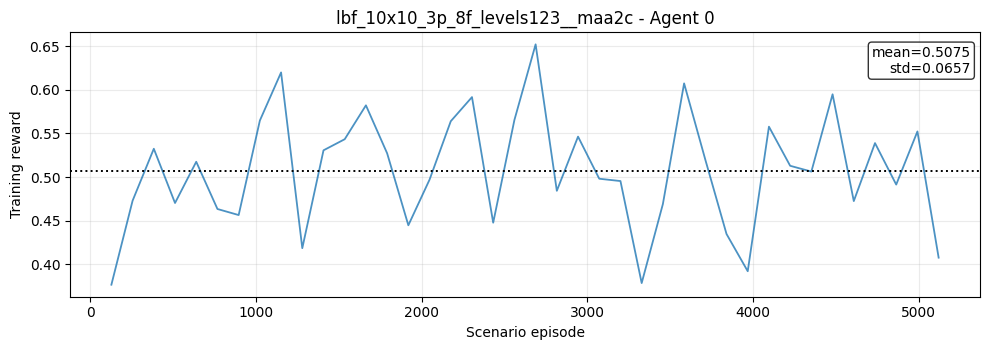

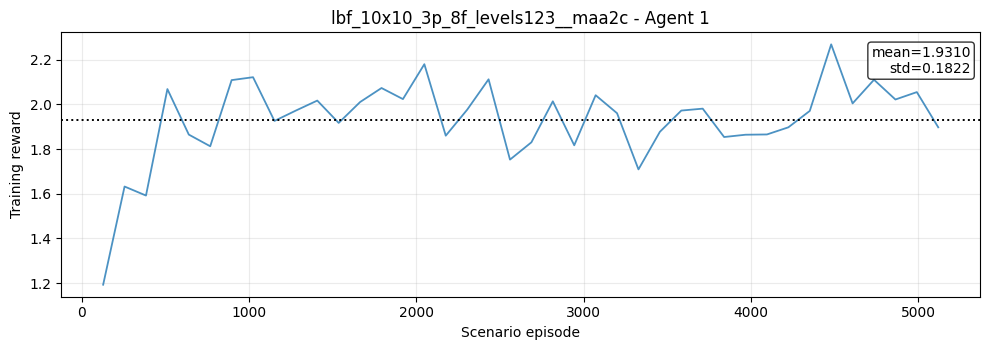

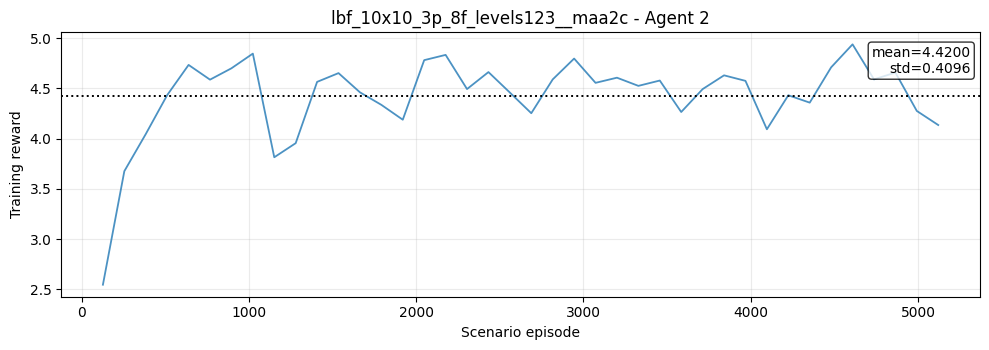

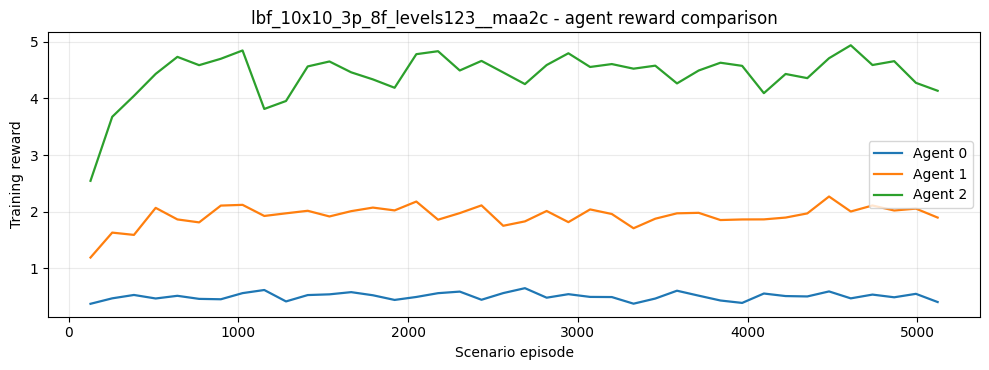

In [9]:
maa2c_training_figs = plot_training_rewards(records_maa2c)


## MAA2C Evaluation Rollouts

For each scenario: run checkpoint evaluation episodes, save/link the first trained-agent rollout GIF, then show one per-agent reward boxplot.


MAA2C lbf_8x8_2p_2f_levels12 checkpoint eval (100 episode) returncode=0
size='scalable')) = 11.05
[DEBUG 14:27:38] matplotlib.font_manager findfont: score(FontEntry(fname='/usr/share/fonts/truetype/dejavu/DejaVuSerif.ttf', name='DejaVu Serif', style='normal', variant='normal', weight=400, stretch='normal', size='scalable')) = 10.05
[DEBUG 14:27:38] matplotlib.font_manager findfont: score(FontEntry(fname='/usr/share/fonts/truetype/ubuntu/Ubuntu-MI.ttf', name='Ubuntu', style='italic', variant='normal', weight=400, stretch='normal', size='scalable')) = 11.05
[DEBUG 14:27:38] matplotlib.font_manager findfont: score(FontEntry(fname='/usr/share/fonts/truetype/ubuntu/Ubuntu-C.ttf', name='Ubuntu', style='normal', variant='normal', weight=400, stretch='normal', size='scalable')) = 10.05
[DEBUG 14:27:38] matplotlib.font_manager findfont: score(FontEntry(fname='/usr/share/fonts/truetype/ubuntu/Ubuntu-LI.ttf', name='Ubuntu', style='italic', variant='normal', weight=400, stretch='normal', size='sca

/home/wowthecoder/SRE-DQN/discrete_action_space/lbf_grid/baseline_runs/epymarl/lbf_8x8_2p_2f_levels12/maa2c/maa2c_rollout.gif

[checkpoint rollout video saved: /home/wowthecoder/SRE-DQN/discrete_action_space/lbf_grid/baseline_runs/epymarl/lbf_8x8_2p_2f_levels12/maa2c/maa2c_rollout.gif]


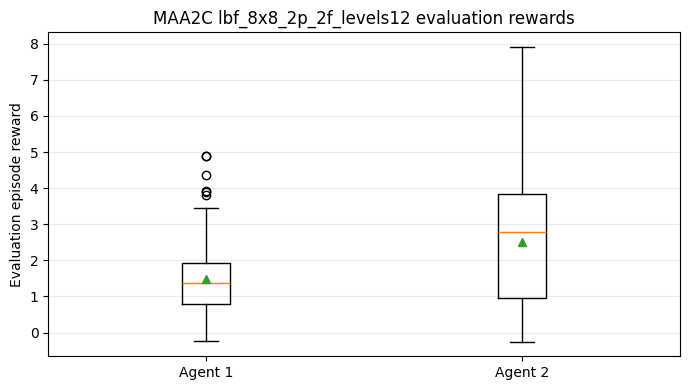

MAA2C lbf_8x8_2p_2f_force_coop checkpoint eval (100 episode) returncode=0
size='scalable')) = 11.05
[DEBUG 14:28:05] matplotlib.font_manager findfont: score(FontEntry(fname='/usr/share/fonts/truetype/dejavu/DejaVuSerif.ttf', name='DejaVu Serif', style='normal', variant='normal', weight=400, stretch='normal', size='scalable')) = 10.05
[DEBUG 14:28:05] matplotlib.font_manager findfont: score(FontEntry(fname='/usr/share/fonts/truetype/ubuntu/Ubuntu-MI.ttf', name='Ubuntu', style='italic', variant='normal', weight=400, stretch='normal', size='scalable')) = 11.05
[DEBUG 14:28:05] matplotlib.font_manager findfont: score(FontEntry(fname='/usr/share/fonts/truetype/ubuntu/Ubuntu-C.ttf', name='Ubuntu', style='normal', variant='normal', weight=400, stretch='normal', size='scalable')) = 10.05
[DEBUG 14:28:05] matplotlib.font_manager findfont: score(FontEntry(fname='/usr/share/fonts/truetype/ubuntu/Ubuntu-LI.ttf', name='Ubuntu', style='italic', variant='normal', weight=400, stretch='normal', size='s

/home/wowthecoder/SRE-DQN/discrete_action_space/lbf_grid/baseline_runs/epymarl/lbf_8x8_2p_2f_force_coop/maa2c/maa2c_rollout.gif

[checkpoint rollout video saved: /home/wowthecoder/SRE-DQN/discrete_action_space/lbf_grid/baseline_runs/epymarl/lbf_8x8_2p_2f_force_coop/maa2c/maa2c_rollout.gif]


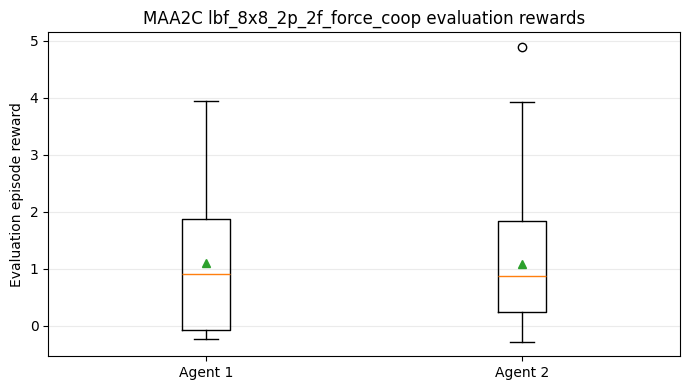

MAA2C lbf_10x10_3p_8f_levels123 checkpoint eval (100 episode) returncode=0
indfont: score(FontEntry(fname='/usr/share/fonts/truetype/dejavu/DejaVuSerif.ttf', name='DejaVu Serif', style='normal', variant='normal', weight=400, stretch='normal', size='scalable')) = 10.05
[DEBUG 14:28:53] matplotlib.font_manager findfont: score(FontEntry(fname='/usr/share/fonts/truetype/ubuntu/Ubuntu-MI.ttf', name='Ubuntu', style='italic', variant='normal', weight=400, stretch='normal', size='scalable')) = 11.05
[DEBUG 14:28:53] matplotlib.font_manager findfont: score(FontEntry(fname='/usr/share/fonts/truetype/ubuntu/Ubuntu-C.ttf', name='Ubuntu', style='normal', variant='normal', weight=400, stretch='normal', size='scalable')) = 10.05
[DEBUG 14:28:53] matplotlib.font_manager findfont: score(FontEntry(fname='/usr/share/fonts/truetype/ubuntu/Ubuntu-LI.ttf', name='Ubuntu', style='italic', variant='normal', weight=400, stretch='normal', size='scalable')) = 11.05
[DEBUG 14:28:53] matplotlib.font_manager findfon

/home/wowthecoder/SRE-DQN/discrete_action_space/lbf_grid/baseline_runs/epymarl/lbf_10x10_3p_8f_levels123/maa2c/maa2c_rollout.gif

[checkpoint rollout video saved: /home/wowthecoder/SRE-DQN/discrete_action_space/lbf_grid/baseline_runs/epymarl/lbf_10x10_3p_8f_levels123/maa2c/maa2c_rollout.gif]


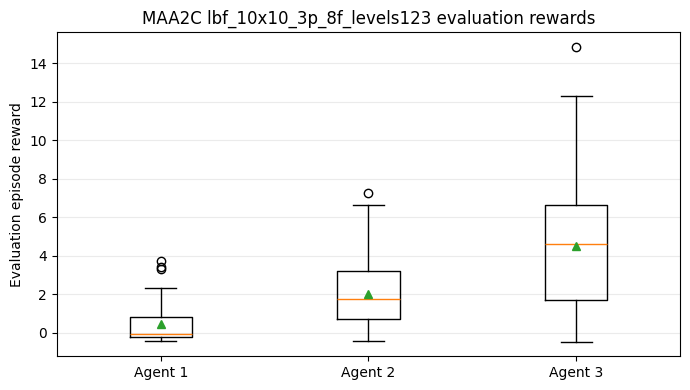

In [10]:
maa2c_eval_rollouts = run_epymarl_evaluation_rollouts(records_maa2c, common_reward=False)
